In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import behavior.behavioral_epoch_tools as bet
sys.path.append(r'c:\Users\zhaoz\Desktop\Research\SocialMemory\diff_fam_social_memory_ephys')

path = r"C:\Users\zhaoz\Desktop\Research\Cooperation\ecu_behaviors"

# Event Durations & Between-event Gaps Durations

In [2]:
box_to_ecu_dict = {
            1: {'dio_ECU_Din1': 'selfish light',
                'dio_ECU_Din2': 'coop light',
                'dio_ECU_Din6': 'selfish nose poke',
                'dio_ECU_Din10': 'coop nose poke',
                'dio_ECU_Din8': 'subject port entry',
                'dio_ECU_Din16': 'recipient port entry'},   
            2: {'dio_ECU_Din3': 'selfish light',
                'dio_ECU_Din4': 'coop light',
                'dio_ECU_Din22': 'selfish nose poke',
                'dio_ECU_Din26': 'coop nose poke',
                'dio_ECU_Din24': 'subject port entry',
                'dio_ECU_Din32': 'recipient port entry'}}

In [3]:
def pickle_this(thing_to_pickle, file_name):
    """
    Pickles things
    Args (2):   
        thing_to_pickle: anything you want to pickle
        file_name: str, filename that ends with .pkl 
    Returns:
        none
    """
    with open(file_name,'wb') as file:
        pickle.dump(thing_to_pickle, file)

def unpickle_this(pickle_file):
    """
    Unpickles things
    Args (1):   
        file_name: str, pickle filename that already exists and ends with .pkl
    Returns:
        pickled item
    """
    with open(pickle_file, 'rb') as file:
        return(pickle.load(file))

## Unpickle Behavior Dictionaries

In [8]:
Stage4 = []
for root, dirs, files in os.walk(path):
	for file in files:
		if file.endswith('.pkl'):
			day_rec = unpickle_this(os.path.join(path, file))
			Stage4.append(day_rec)
print(len(Stage4))
print(Stage4[1].keys())

16
dict_keys(['20250509_094358_Stage4_D2_1-2_merged', '20250509_094358_Stage4_D2_1-3_merged', '20250509_094358_Stage4_D2_2-1_merged', '20250509_110531_Stage4_D2_6-1_merged', '20250509_110531_Stage4_D2_6-3_merged', '20250510_130636_Stage4_D2_4-3_merged', '20250510_130636_Stage4_D2_4-4_merged'])


## 1. Event Durations

In [5]:
def events_duration_distribution(behaviors_dict, behavior, xmin=0, xmax=6, mode='multiple recordings', stage=4, day=0):
	'''
	Plot a histogram of event durations for a given behavior

	Args (2):
		behaviors_dict: dictionary, a nested dictionary with the structure:
			{
				"recording_id": {
					"behavior_name": np.ndarray of shape (n, 2),
					...
				},
				...
			}
		behavior: str, the single behavior that will be plotted
	'''
	if mode == 'single recording': 
		behavior_array = np.array(behaviors_dict[behavior])
	elif mode == 'multiple recordings':
		behavior_array = []
		for rec, rec_behaviors in behaviors_dict.items():
			if len(rec_behaviors[behavior]) > 0:
				for event in rec_behaviors[behavior]:
					behavior_array.append(event)
		behavior_array = np.array(behavior_array)
	
	durations = behavior_array[:, 1] - behavior_array[:, 0]
	
	# Plotting
	plt.figure(figsize=(12, 5))
	plt.hist(durations, bins=30, range=(xmin, xmax), color='#15616F', edgecolor="black")
	plt.title(f"Distribution of Event Durations - {mode} - Stage{stage} Day{day}", fontsize=16)
	plt.xlabel(f"{behavior} event durations (seconds)", fontsize=14)
	plt.ylabel("# of Events", fontsize=14)
	ticks = np.linspace(xmin, xmax, 10)
	plt.xticks(np.round(ticks, 2))
	plt.show()

### a. Single recording example - Stage 4 Day 1 1-2

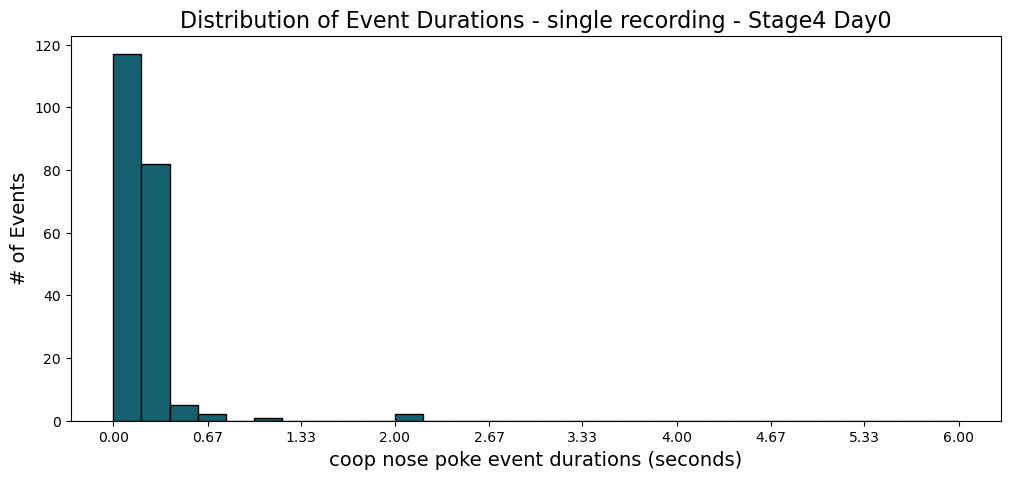

In [ ]:
events_duration_distribution(Stage4[6]['20250516_135729_Stage4_D7_4-1_merged'], "coop nose poke", mode="single recording")

### b. All days in stage 4

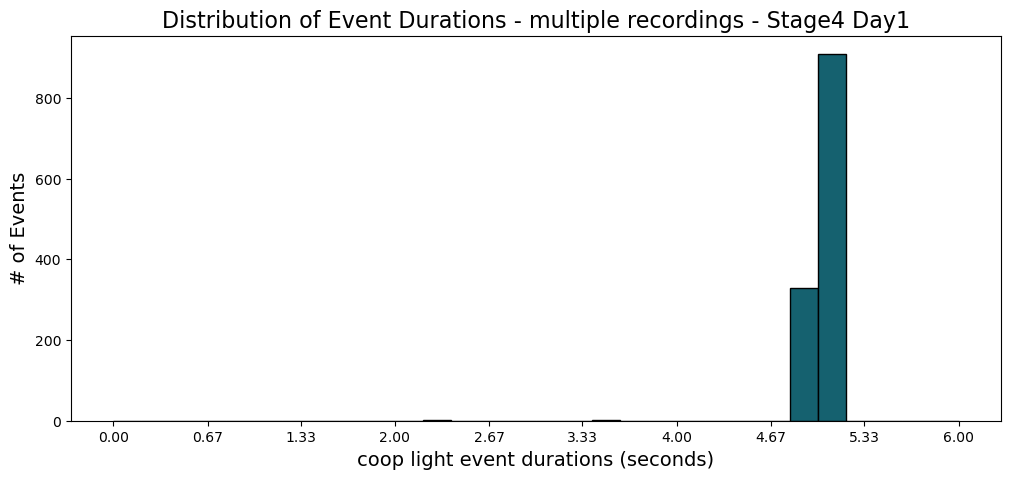

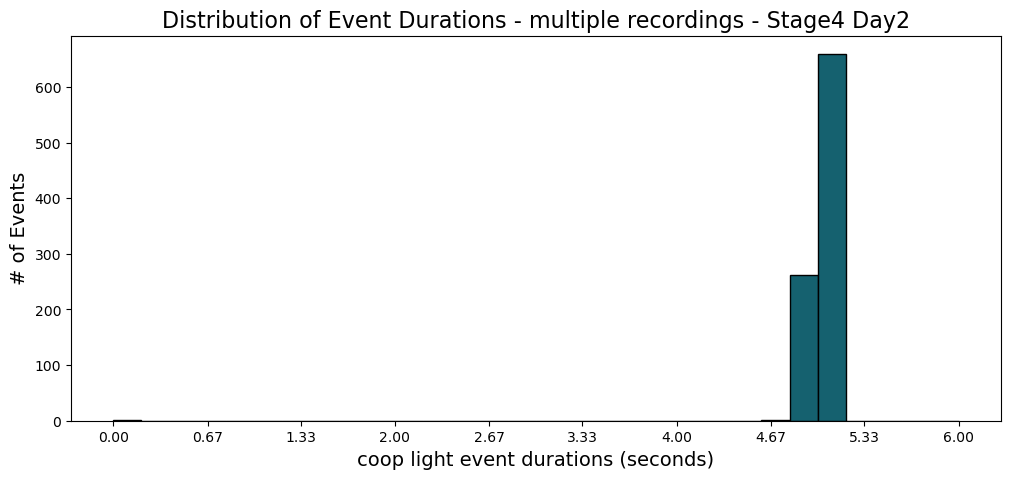

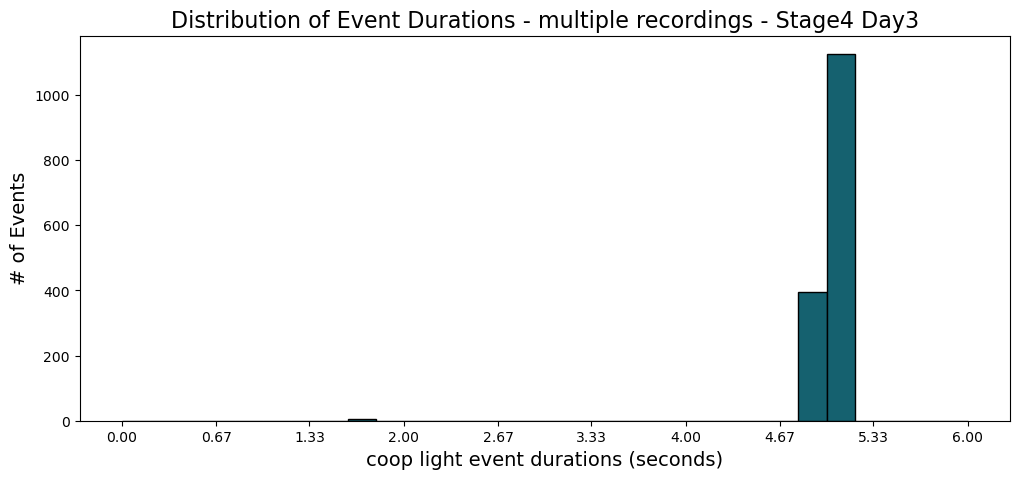

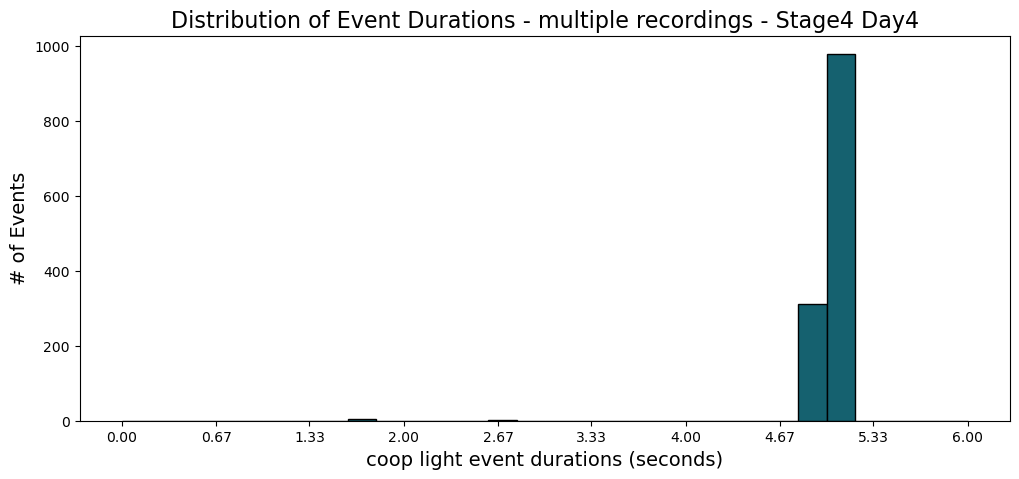

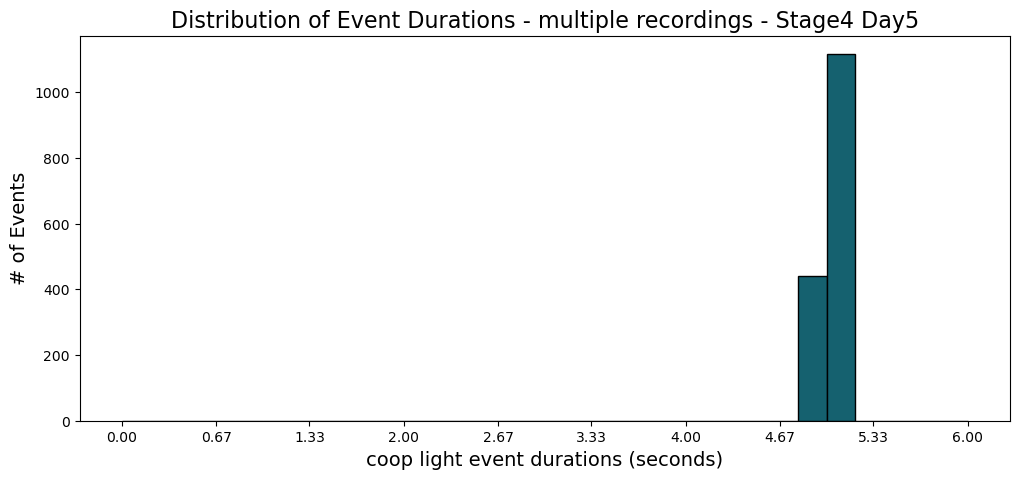

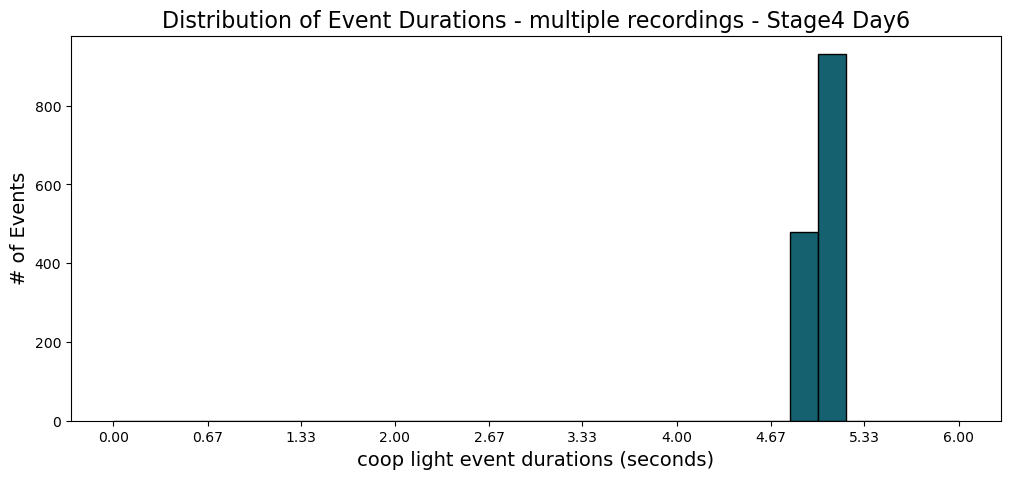

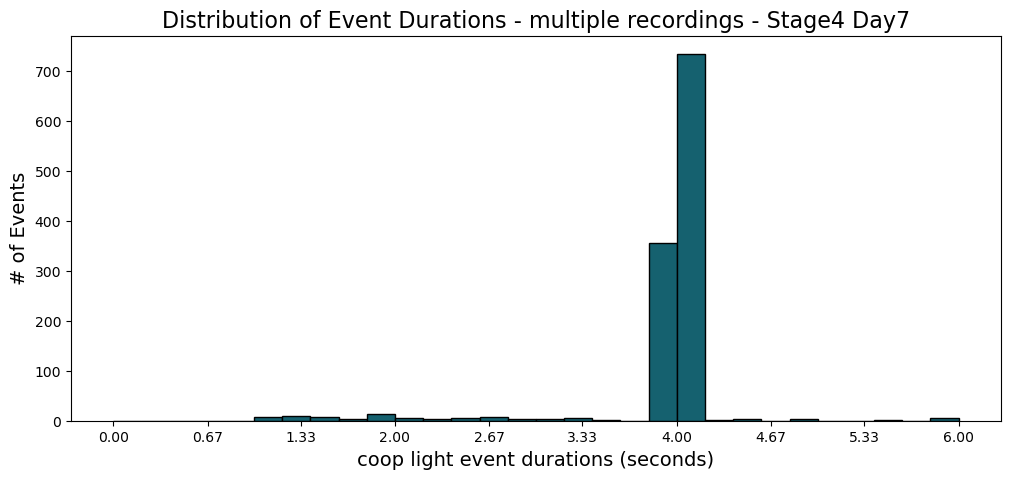

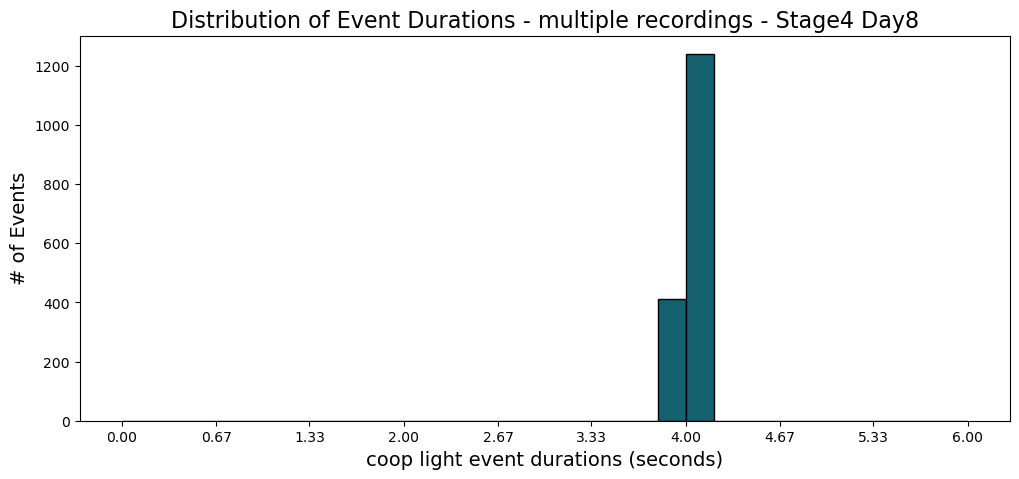

In [ ]:
for i in range(8):
	events_duration_distribution(Stage4[i], "coop light", day= i+1)

## 2. Between-event Gaps Duration

In [8]:
def between_events_duration_distribution(behaviors_dict, behaviors, xmin=0, xmax=10, mode='multiple recordings', stage=4, day=0):
	'''
	Plot a histogram of durations between separate events (can be the same or different behaviors)

	Args (2):
		behaviors_dict: dictionary, a nested dictionary with the structure:
			{
				"recording_id": {
					"behavior_name": np.ndarray of shape (n, 2),
					...
				},
				...
			}
		behaviors: list, a list of behaviors that will be plotted
	'''
	behavior_array = []
	if mode == 'single recording':
		for behavior in behaviors:
			for event in behaviors_dict[behavior]:
				behavior_array.append(event)
		behavior_array.sort(key=lambda x: x[0])
		total_between_event_durations = np.array(behavior_array)[1:, 0] - np.array(behavior_array)[:-1, 1]
		
	elif mode == 'multiple recordings':
		total_between_event_durations = np.array([])
		for rec, rec_behaviors in behaviors_dict.items():
			# skip 6.1 and 6.3 for recipient port entry since they were trained alone
			if (rec.split("_")[4] == '6-1' or rec.split("_")[4] == '6-3') and 'recipient port entry' in behaviors:
				continue

			behavior_array = []
			for behavior in behaviors:
				for event in rec_behaviors[behavior]:
					behavior_array.append(event)
			behavior_array.sort(key=lambda x: x[0])
			rec_between_event_durations = np.array(behavior_array)[1:, 0] - np.array(behavior_array)[:-1, 1]
			total_between_event_durations = np.concatenate((total_between_event_durations, rec_between_event_durations))
	
	print(total_between_event_durations.size)

	plt.figure(figsize=(12, 5))
	plt.hist(total_between_event_durations, bins=50, range=(xmin, xmax), color='#FFAF00', edgecolor="black")
	plt.title(f"Distribution of Between-event Durations - {mode} - Stage{stage} Day{day}", fontsize=16)
	plt.xlabel(f"Time Gaps Between {' & '.join(behaviors)}", fontsize=14)
	plt.ylabel("# of Events", fontsize=14)
	ticks = np.linspace(xmin, xmax, 20)
	plt.xticks(np.round(ticks, 2))
	plt.show()

### a. Single recording example - Stage 4 Day 1 1-2

135


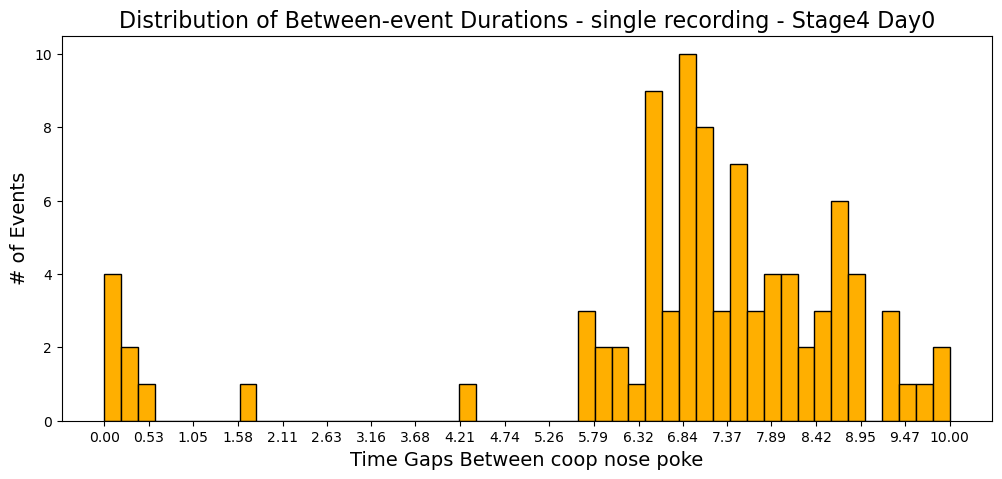

In [9]:
between_events_duration_distribution(Stage4[0]['20250508_100203_Stage4_D1_1-2_merged'], ["coop nose poke"], mode="single recording")

### b. All days in stage 4

2150


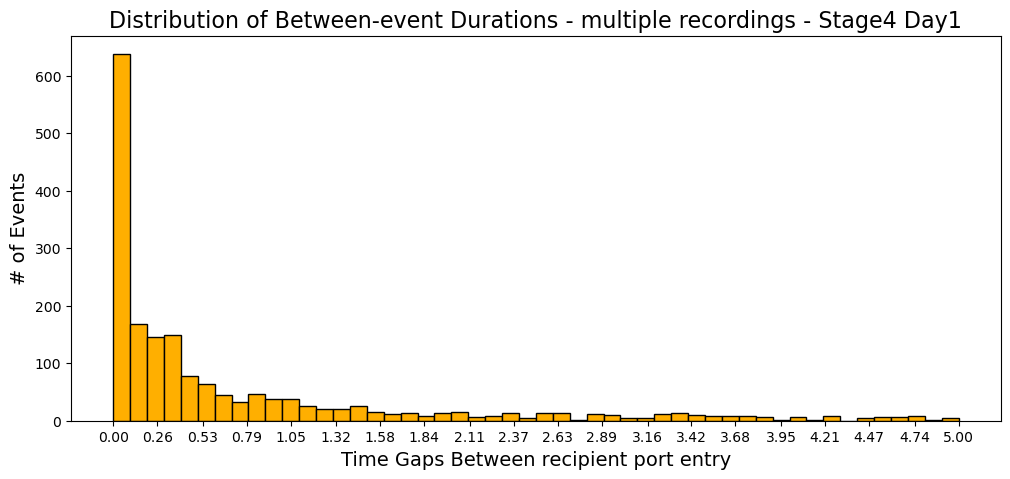

1138


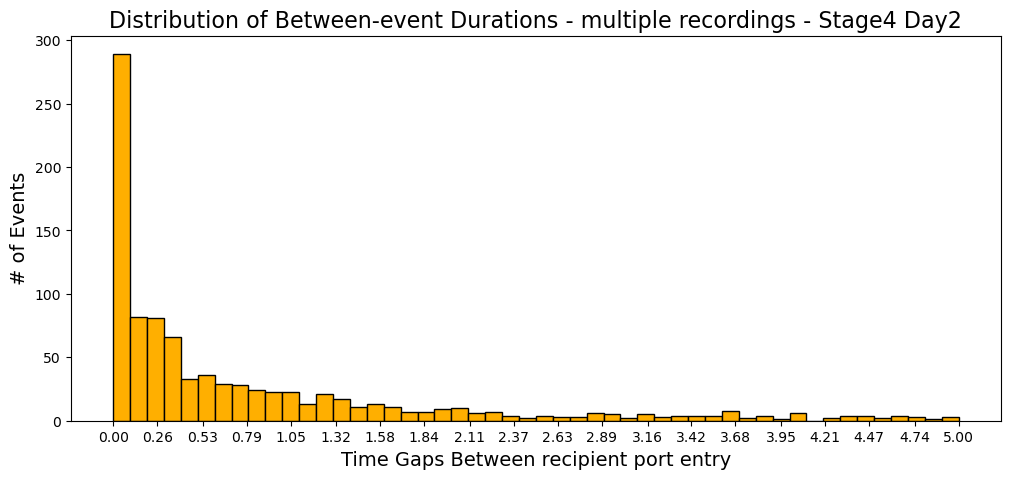

1892


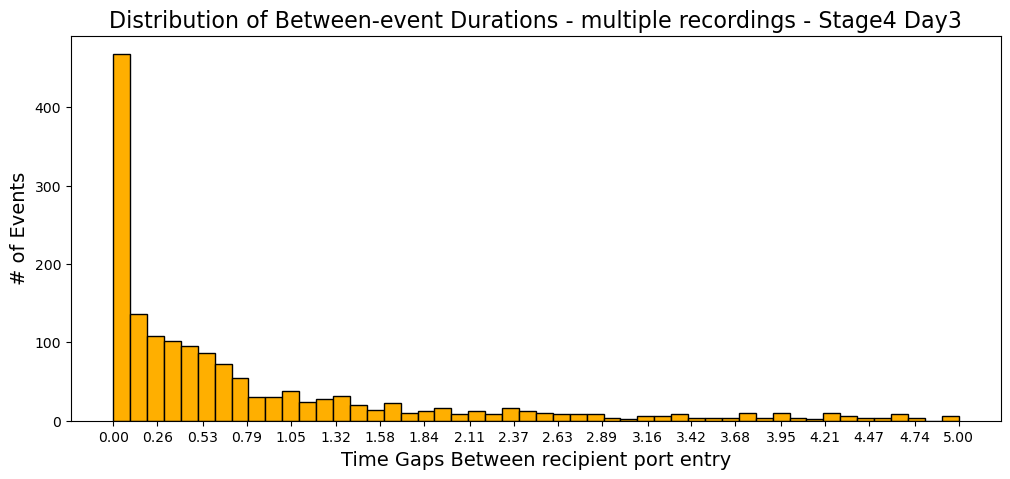

1666


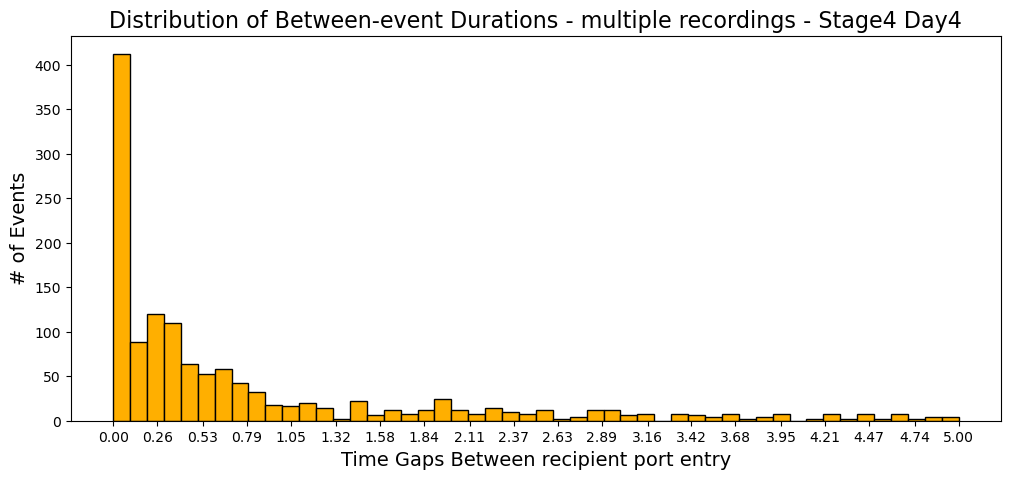

2476


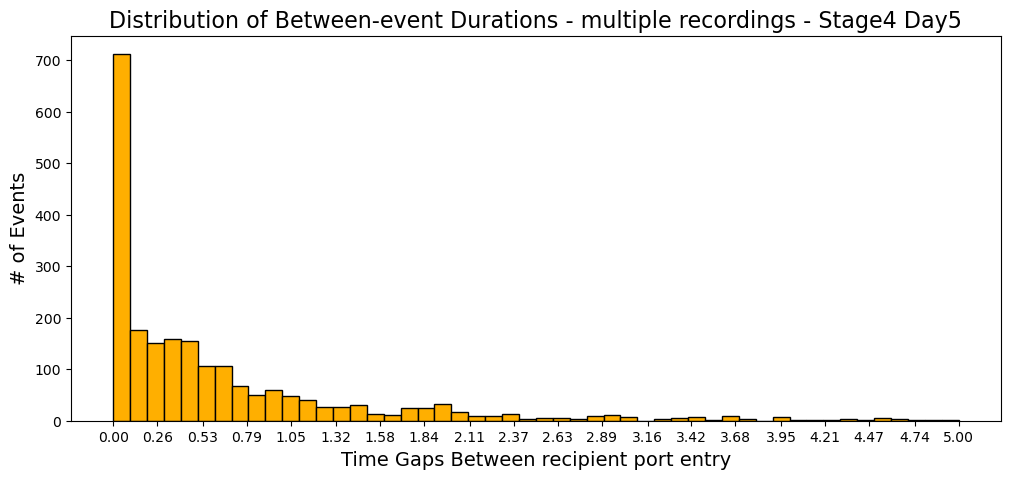

2034


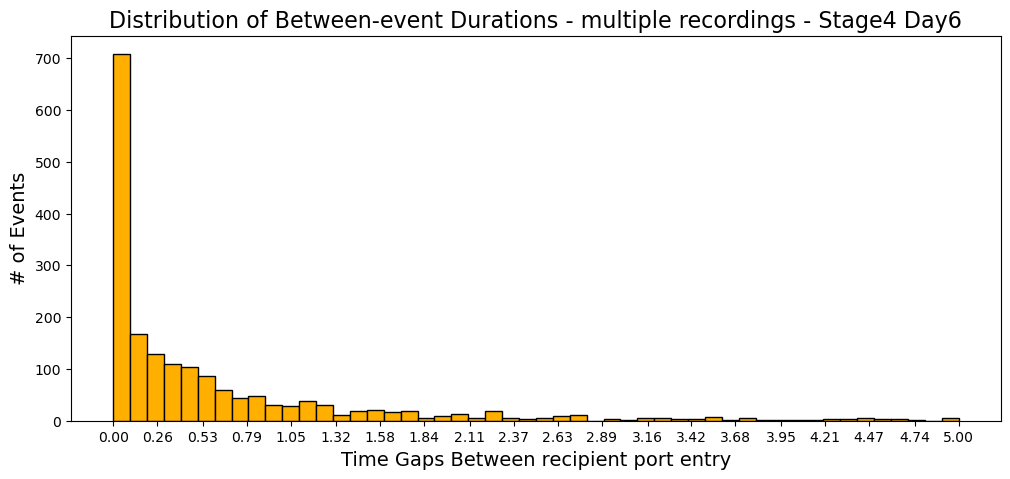

2703


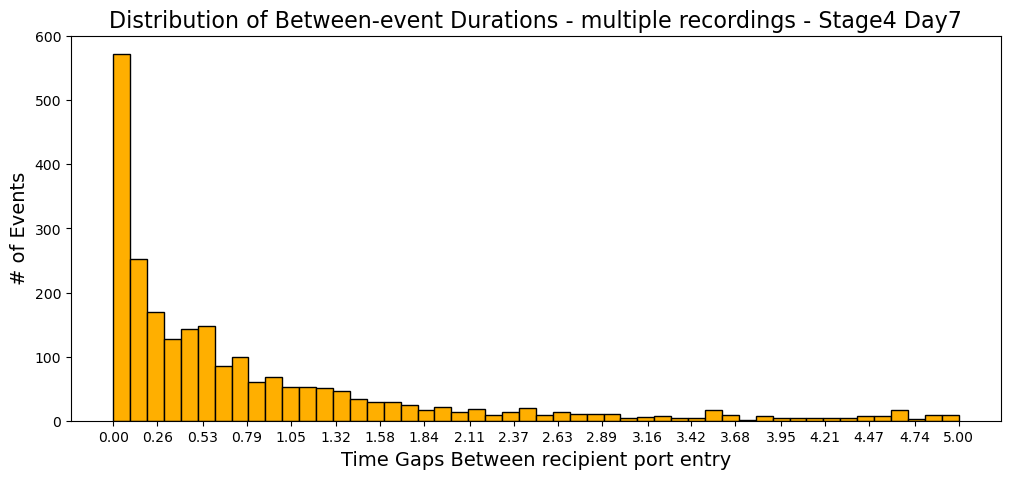

2667


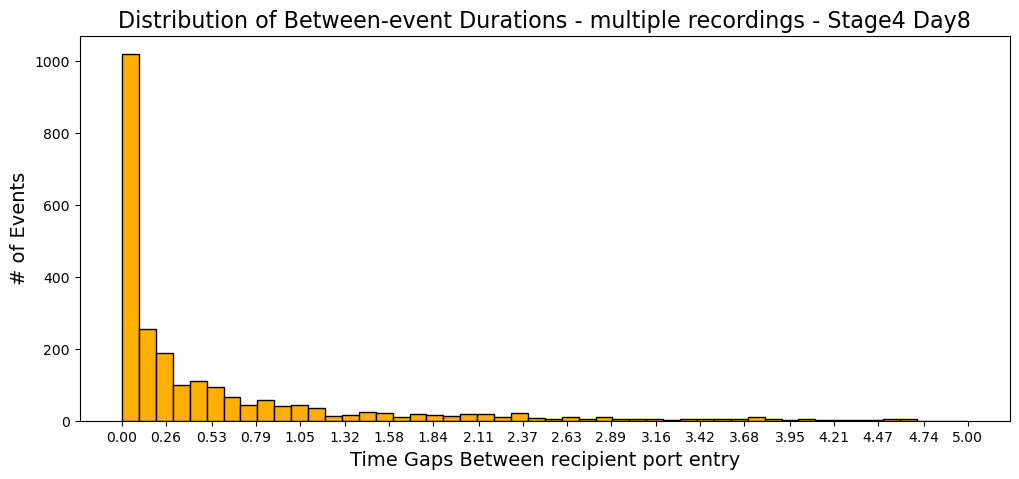

In [10]:
for i in range(8):
	between_events_duration_distribution(Stage4[i], ["recipient port entry"], day= i+1, xmin=0, xmax=5)

## 3. Deal with ITI and Min Bout

In [11]:
Stage4[0]

{'20250508_100203_Stage4_D1_1-2_merged': {'selfish light': [[47.44435,
    52.4442],
   [54.48395, 59.48405],
   [69.57465, 74.57435],
   [76.06425, 81.0643],
   [83.27445, 88.2744],
   [92.2647, 97.2645],
   [100.65455, 105.6546],
   [110.05475, 115.05495],
   [117.51475, 122.5149],
   [126.27485, 131.2749],
   [135.25535, 140.25505],
   [147.7151, 152.7152],
   [160.91525, 165.9155],
   [169.0854, 174.0857],
   [177.2555, 182.2557],
   [187.546, 192.54555],
   [196.2057, 201.2062],
   [204.58595, 209.5859],
   [212.02595, 217.026],
   [222.44605, 227.44635],
   [234.1962, 239.19625],
   [243.08655, 248.08635],
   [250.3164, 255.31635],
   [257.8965, 262.89655],
   [266.6166, 271.6169],
   [273.98685, 278.98675],
   [282.0568, 287.05685],
   [289.647, 294.64695],
   [302.68705, 307.6875],
   [309.95715, 314.95735],
   [318.14725, 323.1474],
   [326.23735, 331.2374],
   [353.9477, 358.94775],
   [361.4879, 366.48785],
   [375.11845, 380.118],
   [397.8082, 402.8084],
   [403.9483, 408.

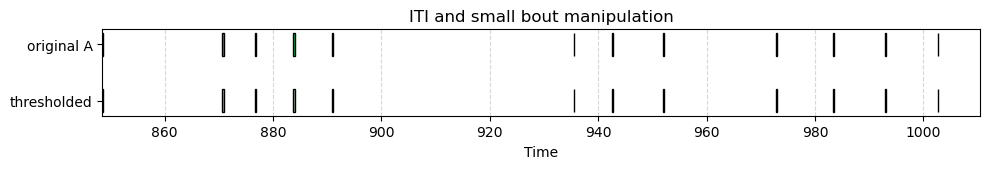

In [12]:
coop_nose_poke_example = Stage4[0]['20250508_100203_Stage4_D1_1-2_merged']['coop nose poke'][57:69]
thresholded = bet.threshold_bouts(coop_nose_poke_example, min_iti = 1, min_bout = 0)
bet.plot_event_bars(coop_nose_poke_example, {'thresholded': thresholded}, title = 'ITI and small bout manipulation')

### a. Between-Evetns ITI After Combining

In [13]:
# Reload the data
Stage4 = []
for root, dirs, files in os.walk(path):
	for file in files:
		if file.endswith('.pkl'):
			day_rec = unpickle_this(os.path.join(path, file))
			Stage4.append(day_rec)
print(len(Stage4))

# Combining events using behavioral_epoch_tools
for i in range(8):
	for rec, behavior_dict in Stage4[i].items():
		behavior_dict['coop nose poke'] = bet.threshold_bouts(behavior_dict['coop nose poke'], min_iti=1, min_bout=0)
		behavior_dict['selfish nose poke'] = bet.threshold_bouts(behavior_dict['selfish nose poke'], min_iti=1, min_bout=0)
		behavior_dict['subject port entry'] = bet.threshold_bouts(behavior_dict['subject port entry'], min_iti=0.8, min_bout=1)
		behavior_dict['recipient port entry'] = bet.threshold_bouts(behavior_dict['recipient port entry'], min_iti=0.1, min_bout=0)

16


### Coop Nose Poke

1300


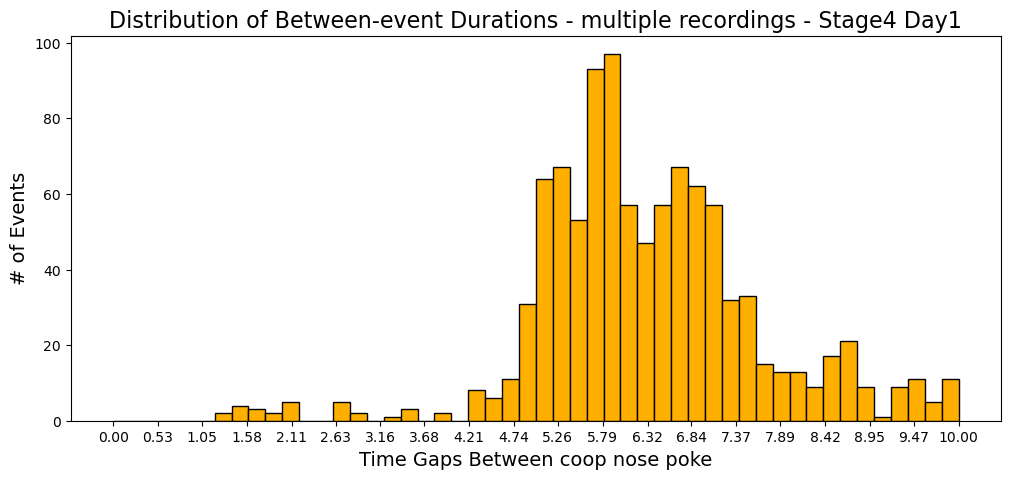

898


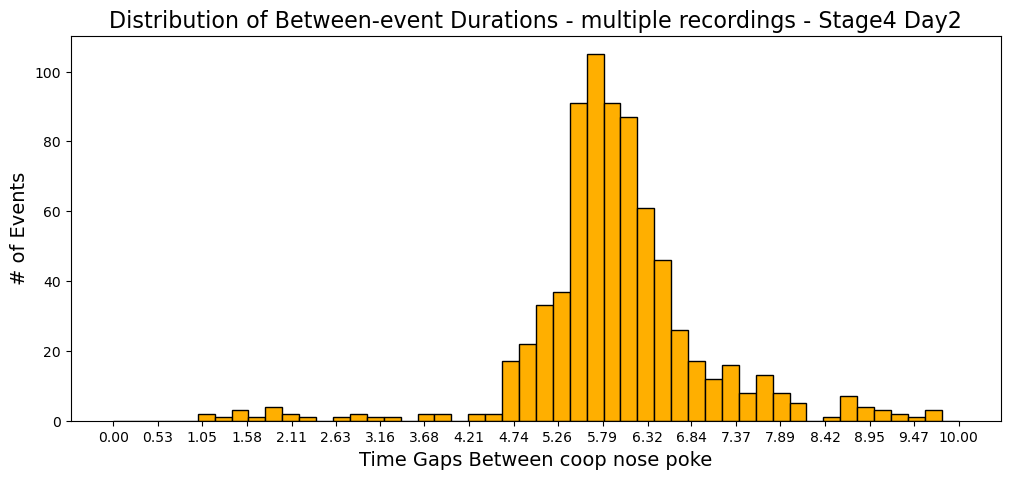

1578


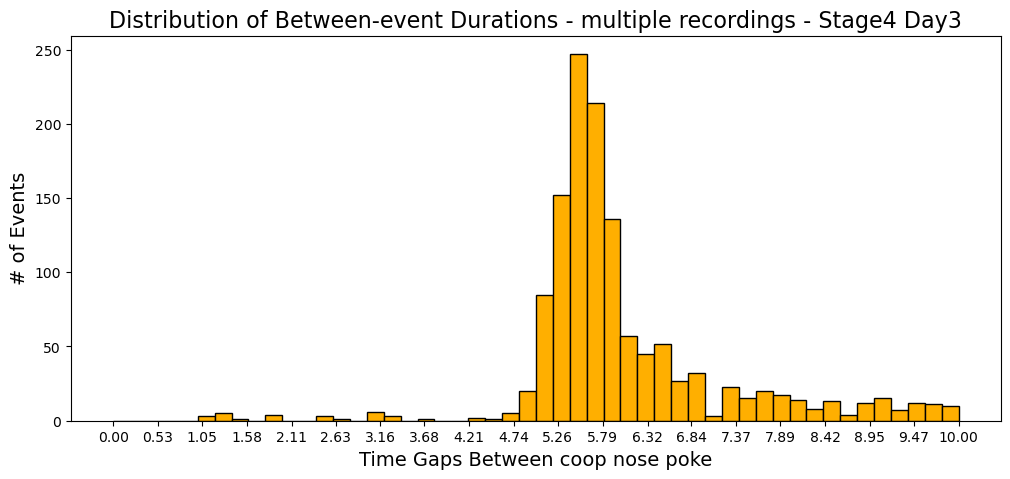

1331


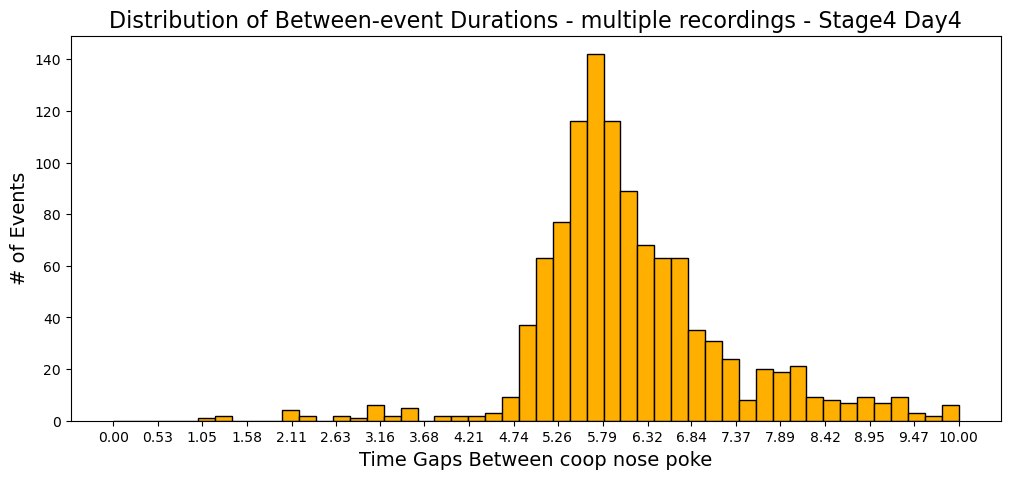

1723


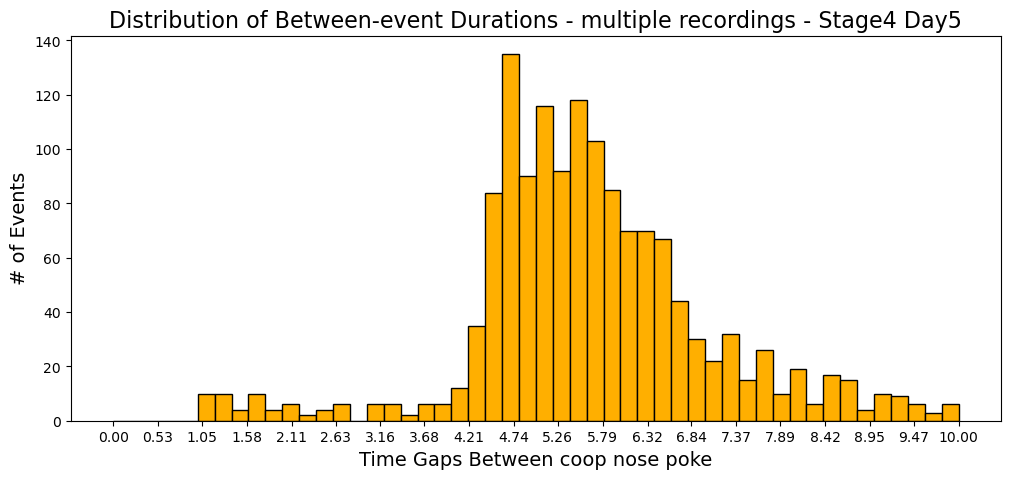

1571


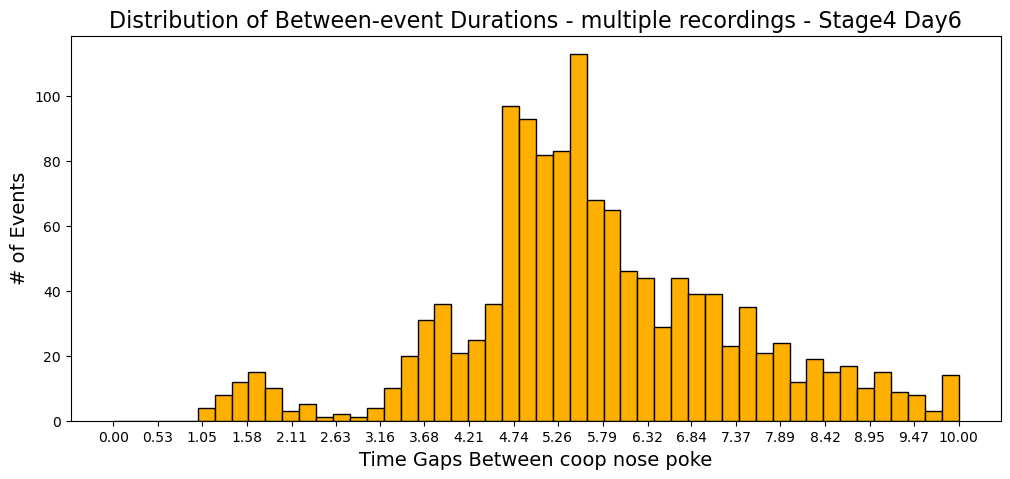

1199


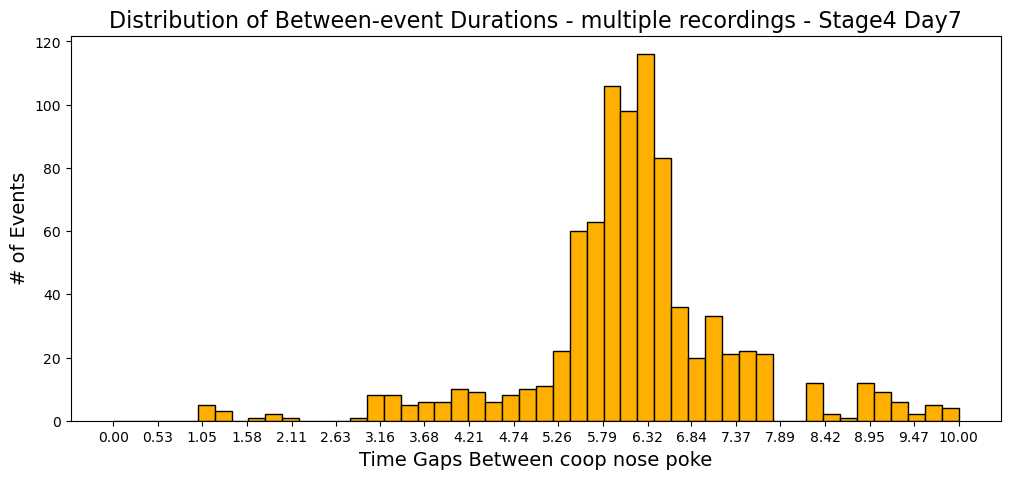

1760


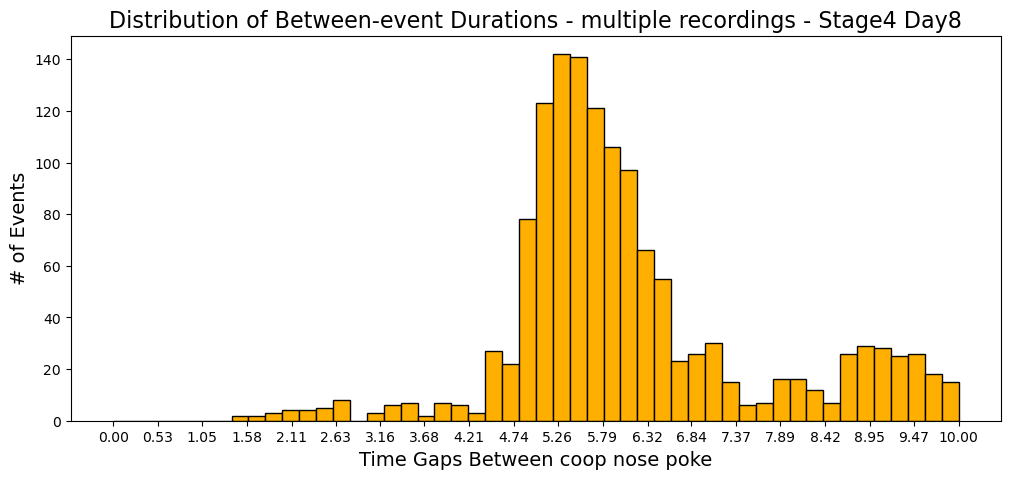

In [14]:
for i in range(8):
	between_events_duration_distribution(Stage4[i], ['coop nose poke'], day= i+1, xmin=0, xmax=10)

### Selfish Nose Poke

810


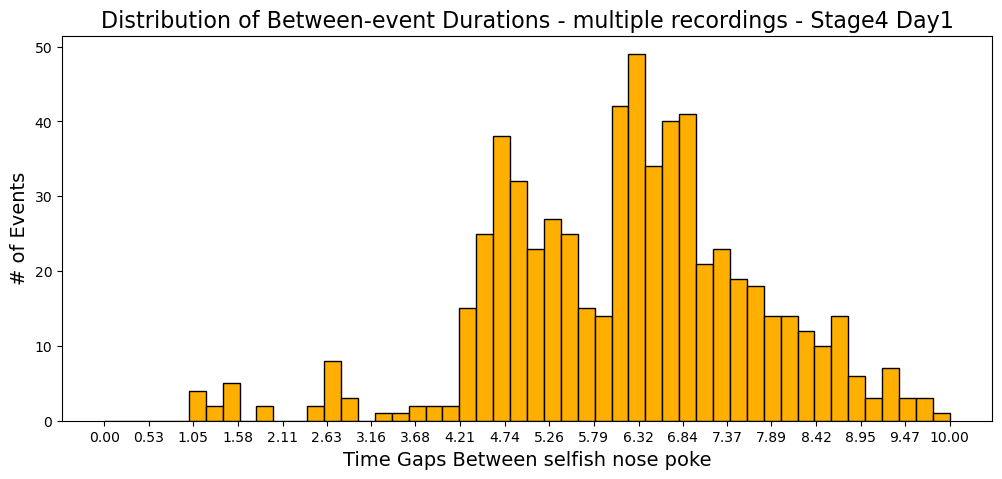

523


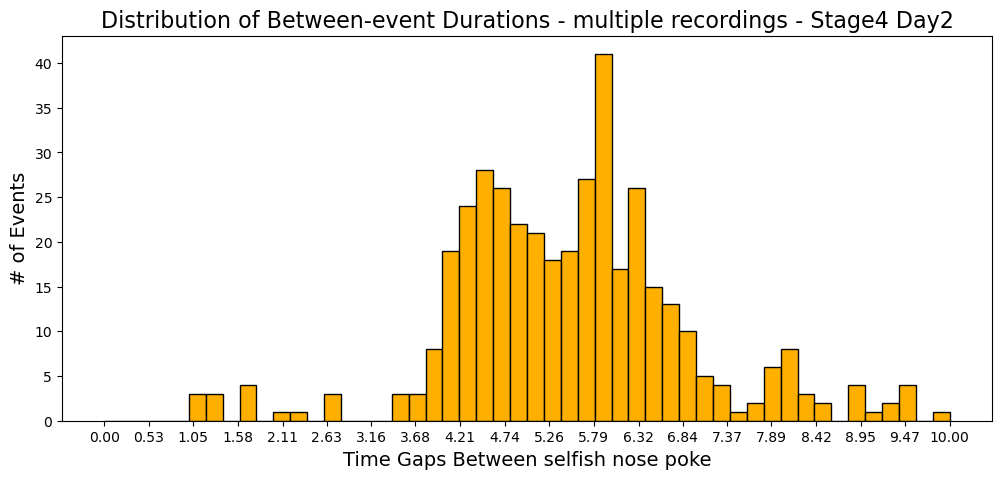

829


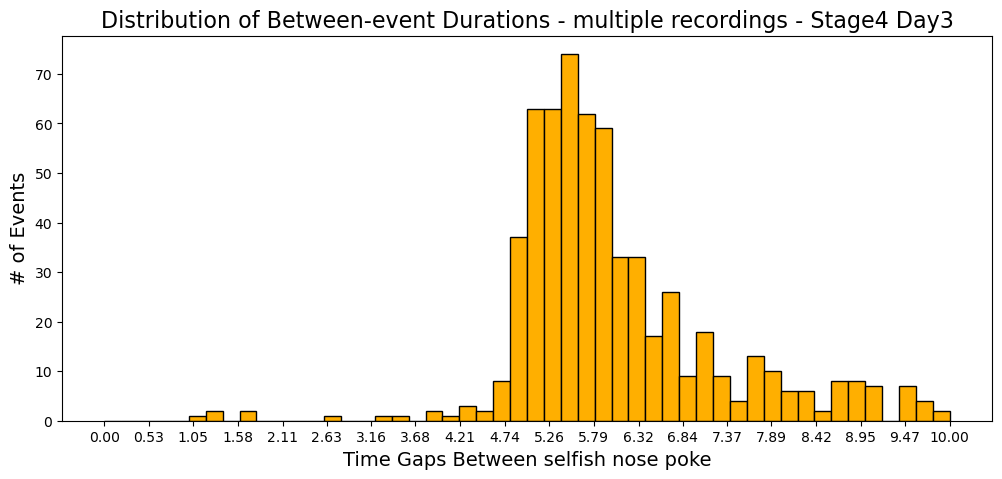

903


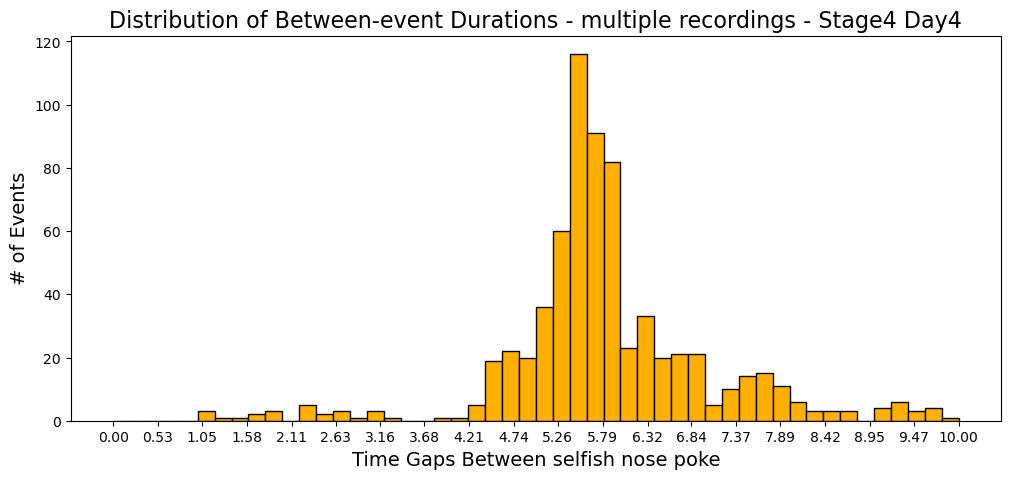

974


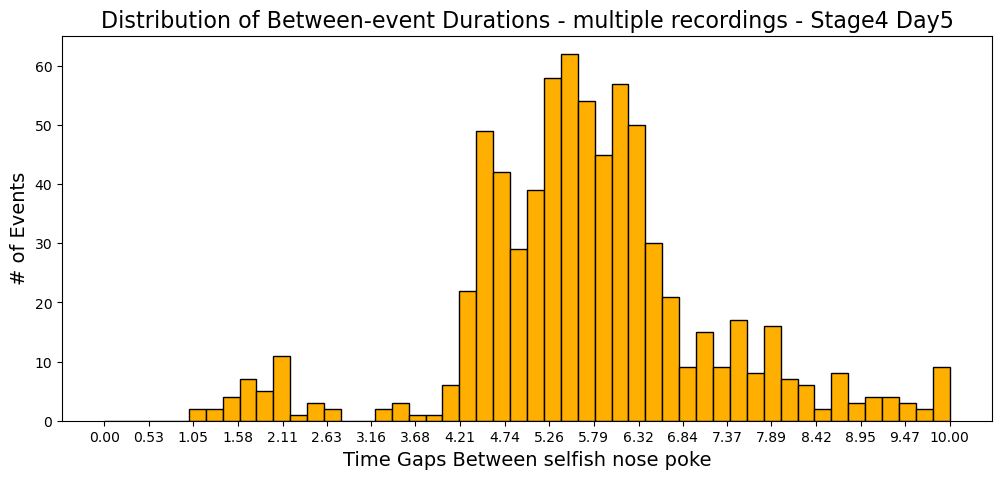

768


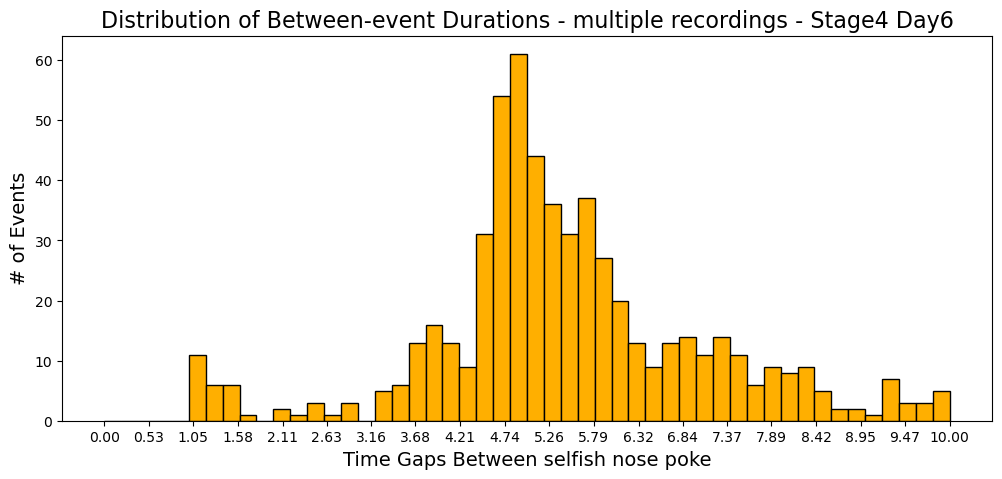

800


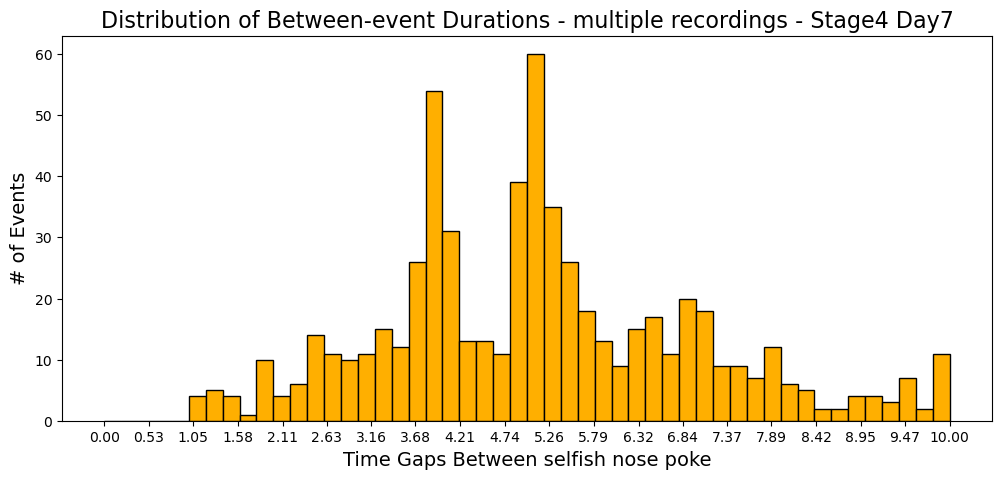

641


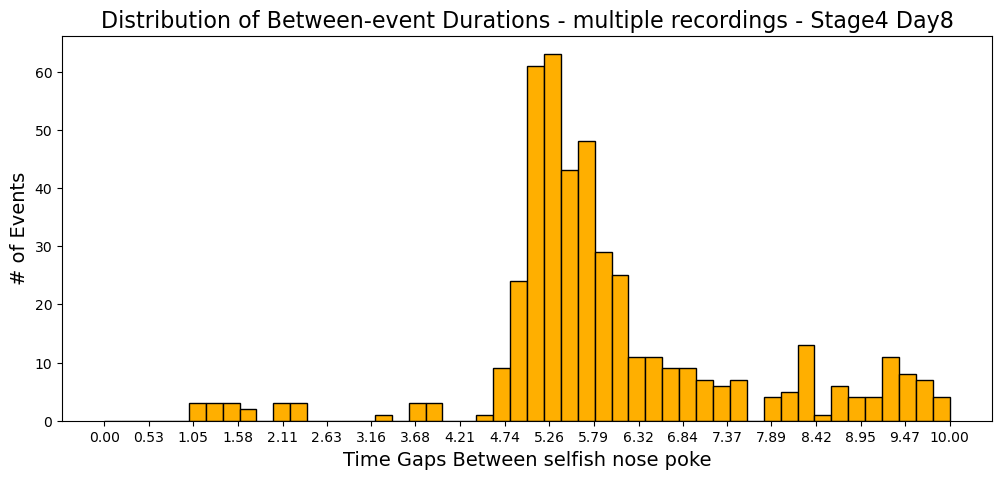

In [15]:
for i in range(8):
	between_events_duration_distribution(Stage4[i], ['selfish nose poke'], day= i+1, xmin=0, xmax=10)

### Subject Port Entry

2077


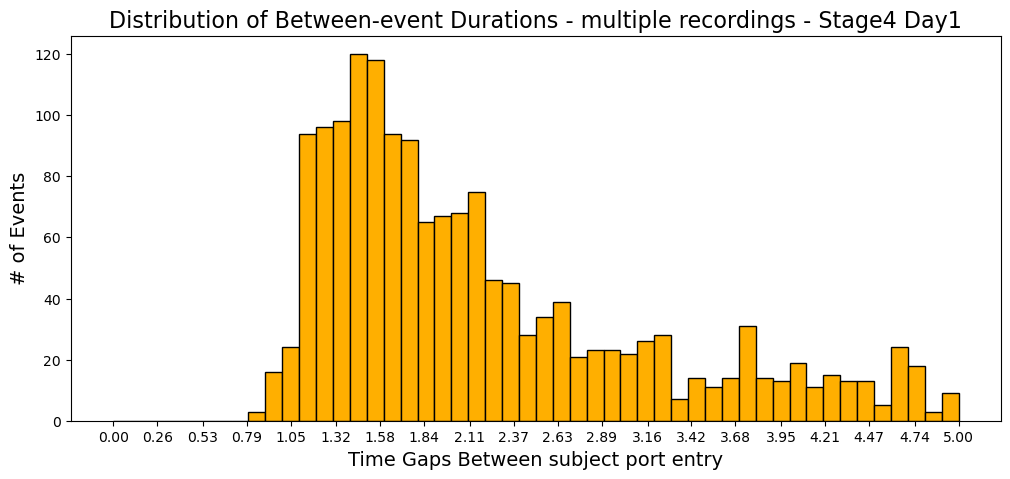

1563


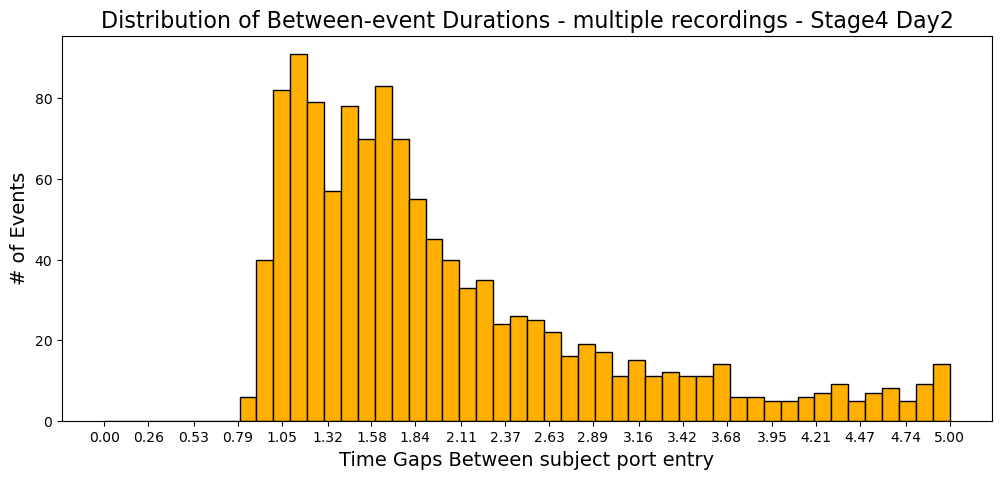

2424


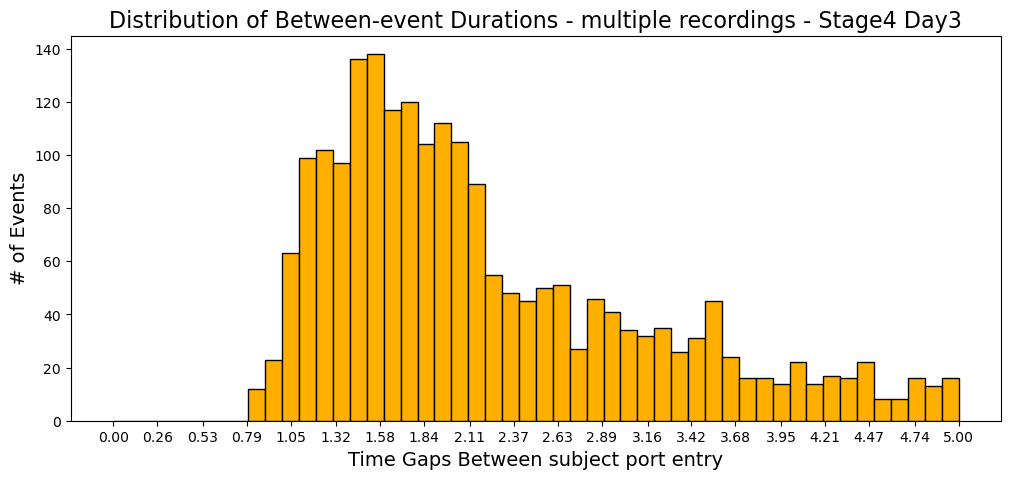

2212


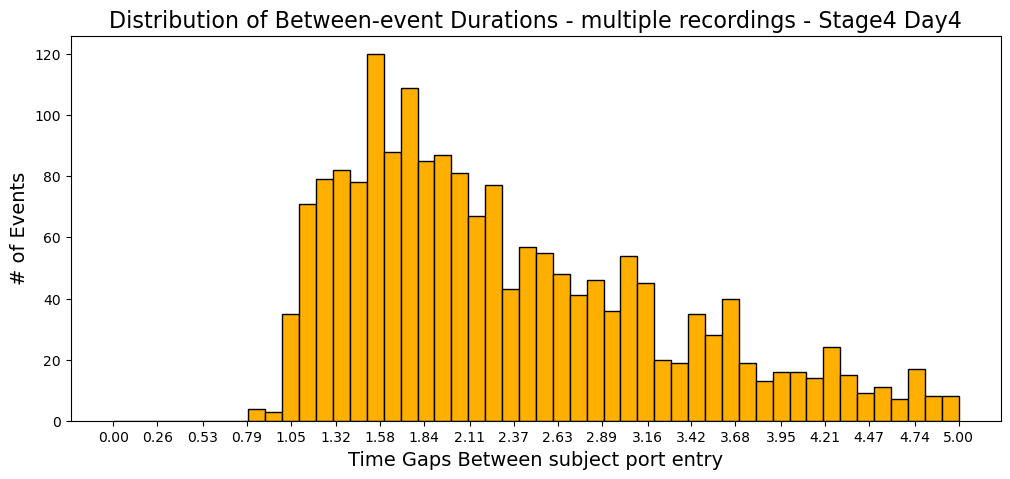

2578


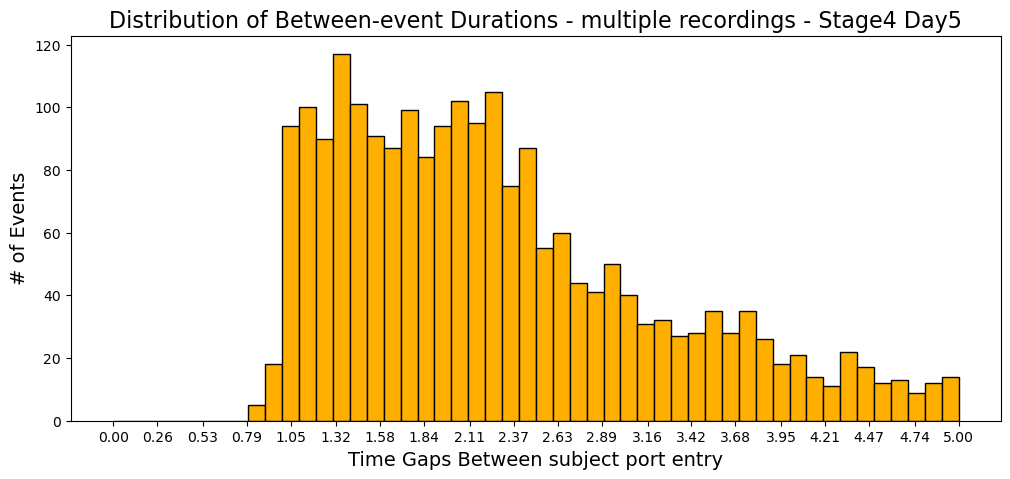

2172


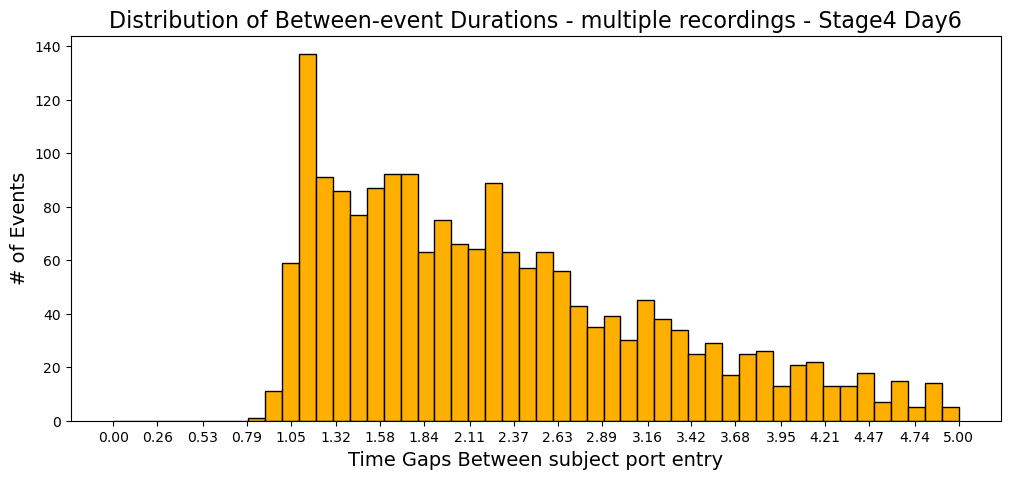

2688


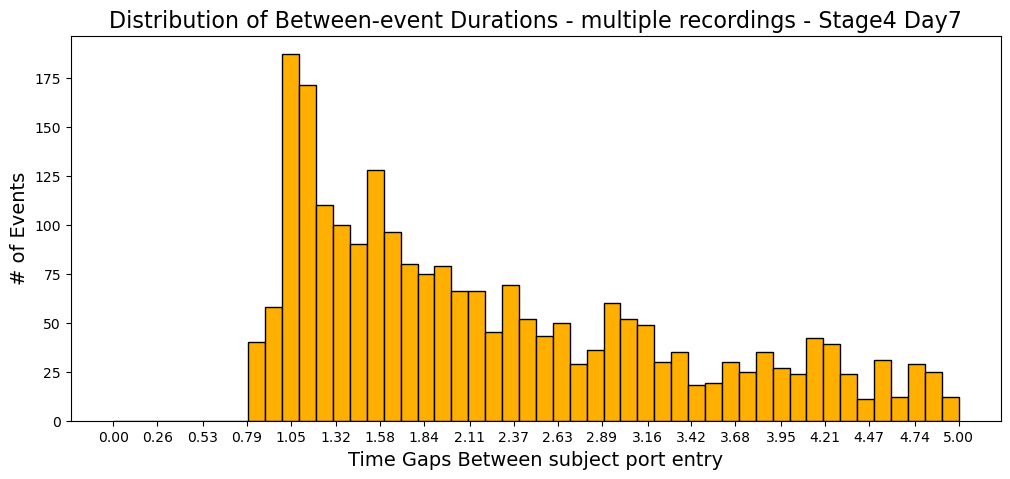

2521


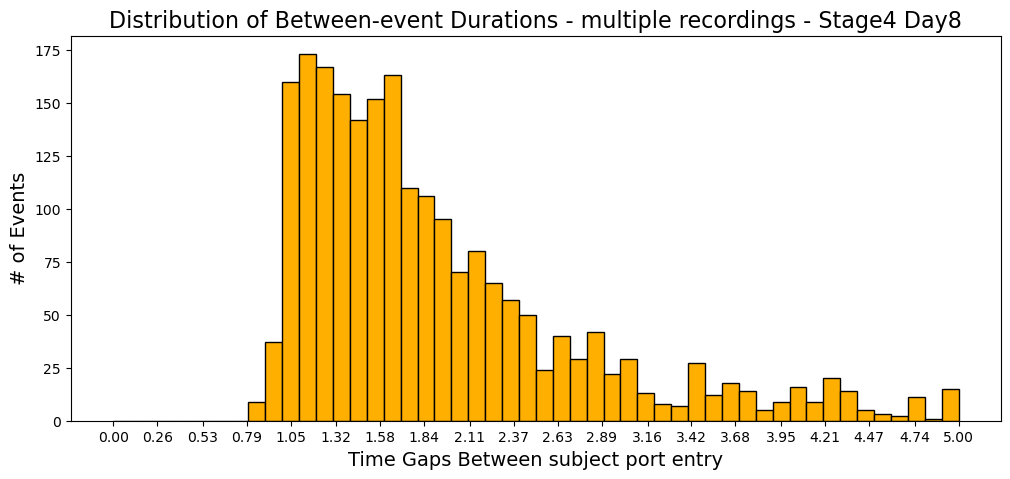

In [16]:
for i in range(8):
	between_events_duration_distribution(Stage4[i], ['subject port entry'], day= i+1, xmin=0, xmax=5)

### Recipient Port Entry

1512


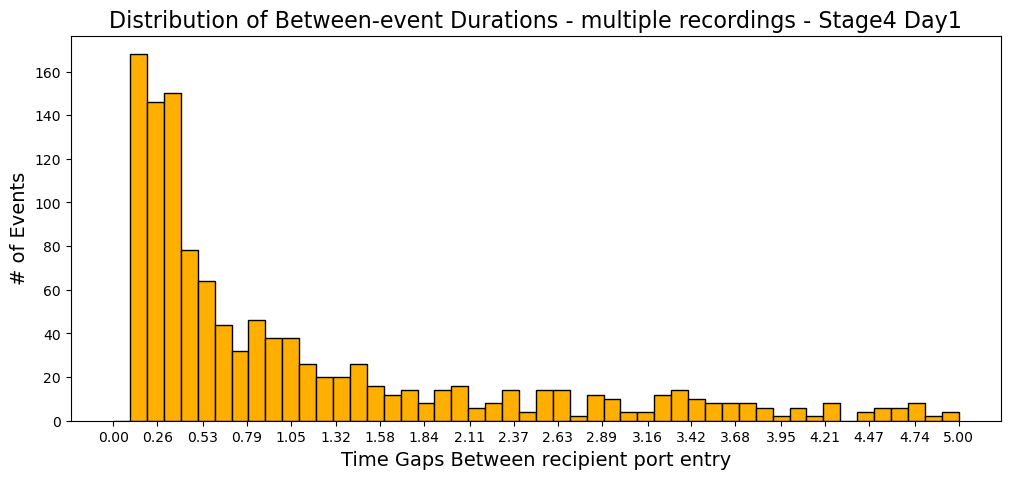

849


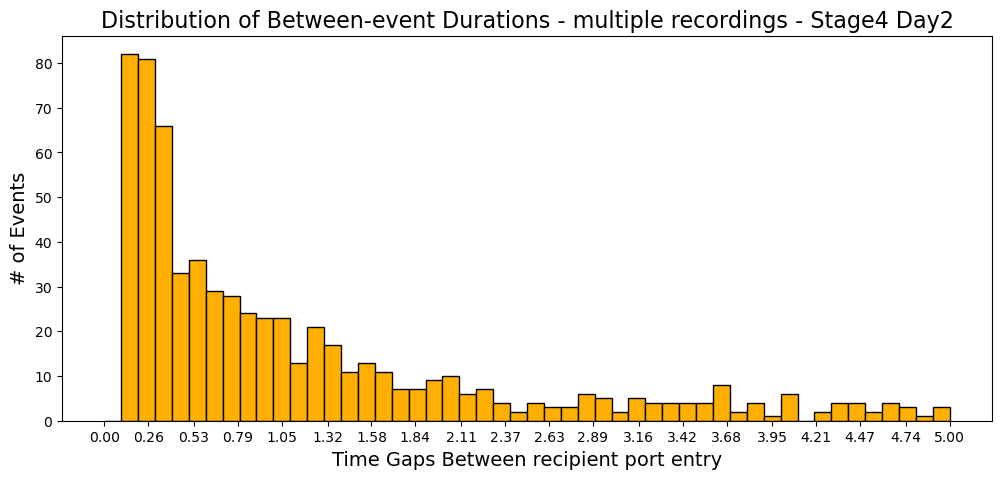

1424


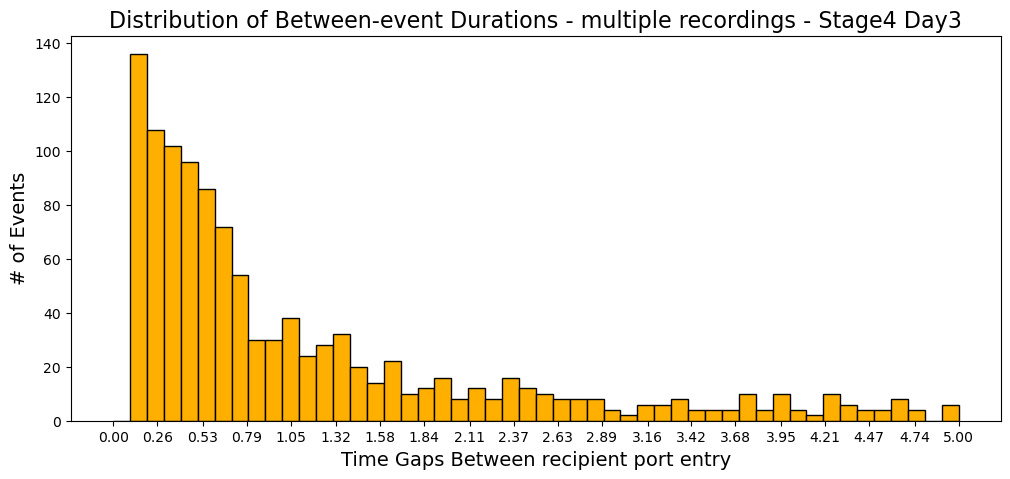

1254


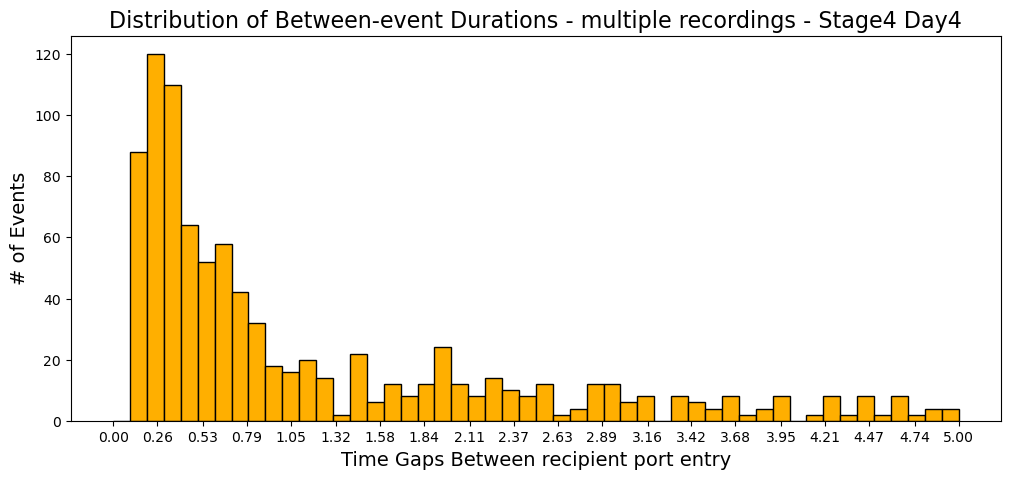

1764


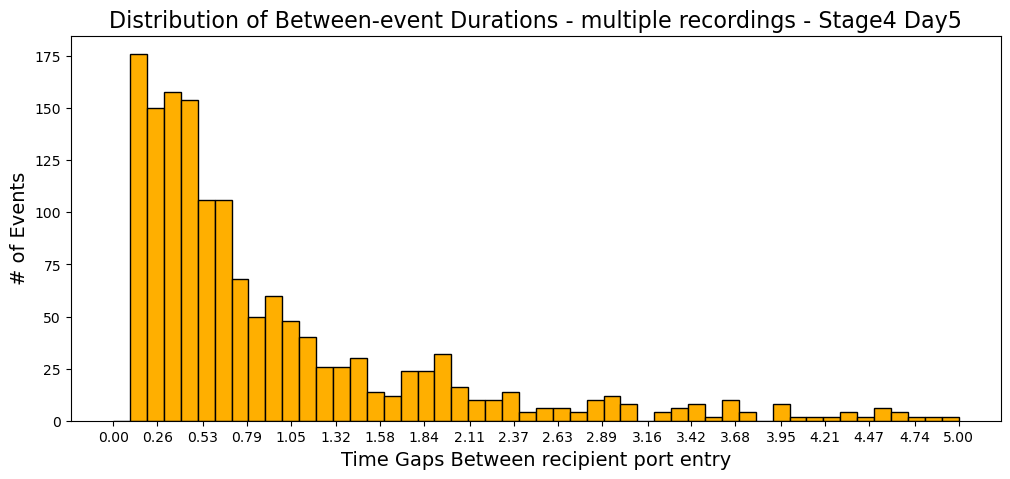

1326


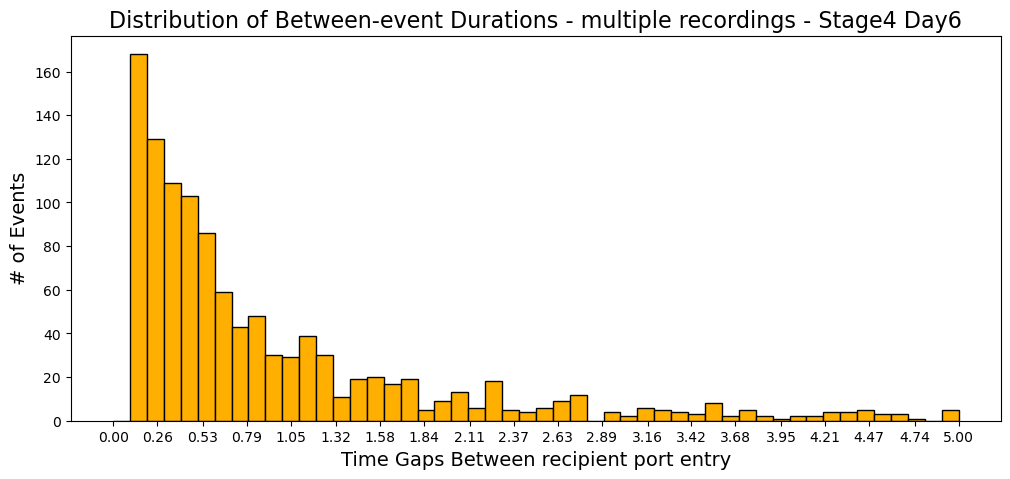

2131


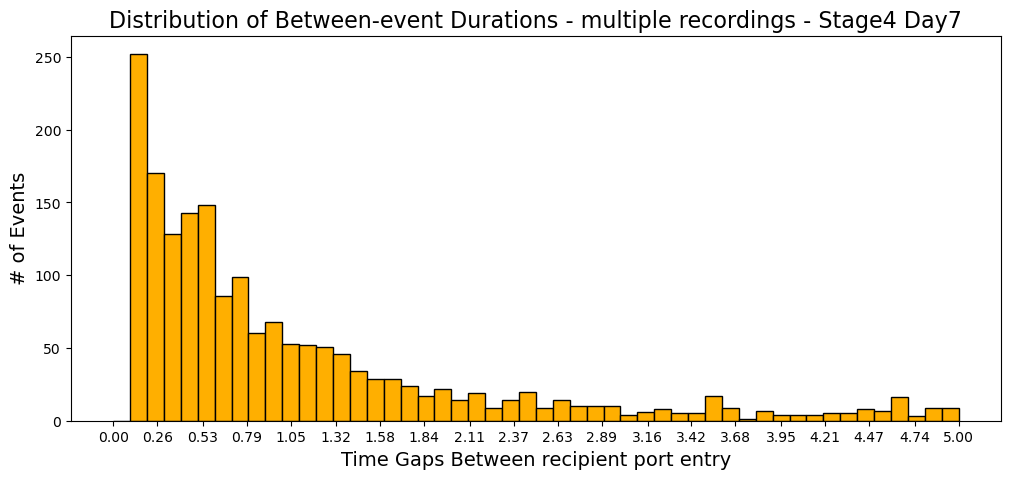

1648


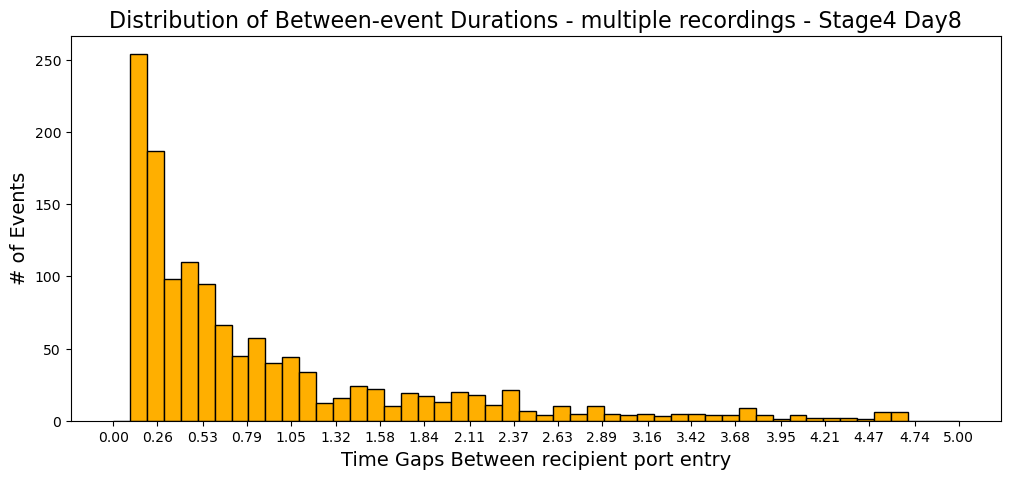

In [17]:
for i in range(8):
	between_events_duration_distribution(Stage4[i], ['recipient port entry'], day= i+1, xmin=0, xmax=5)

### b. Events Duration After Combining
### Coop Nose Poke

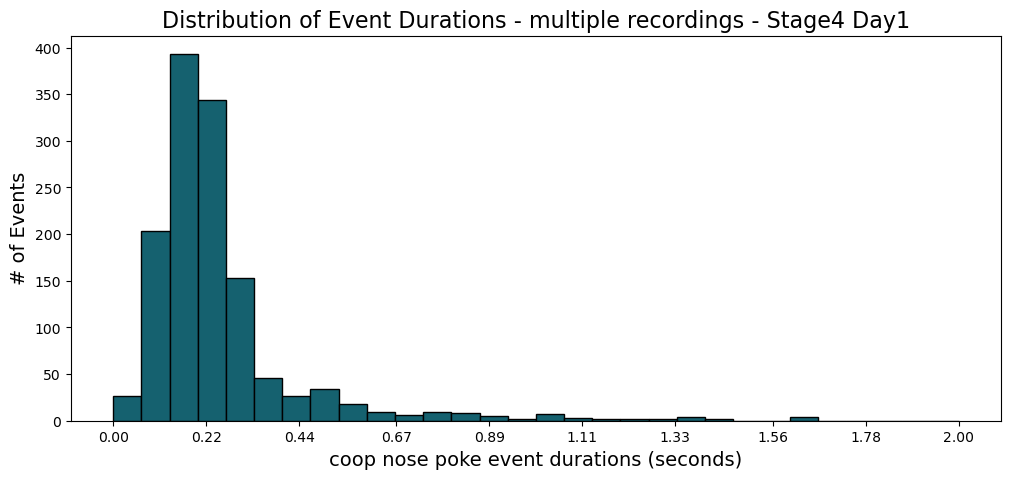

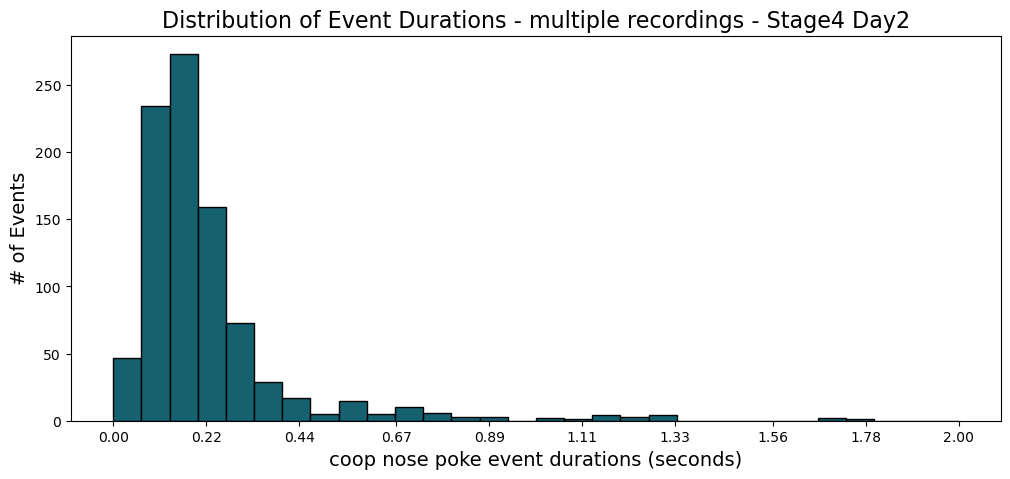

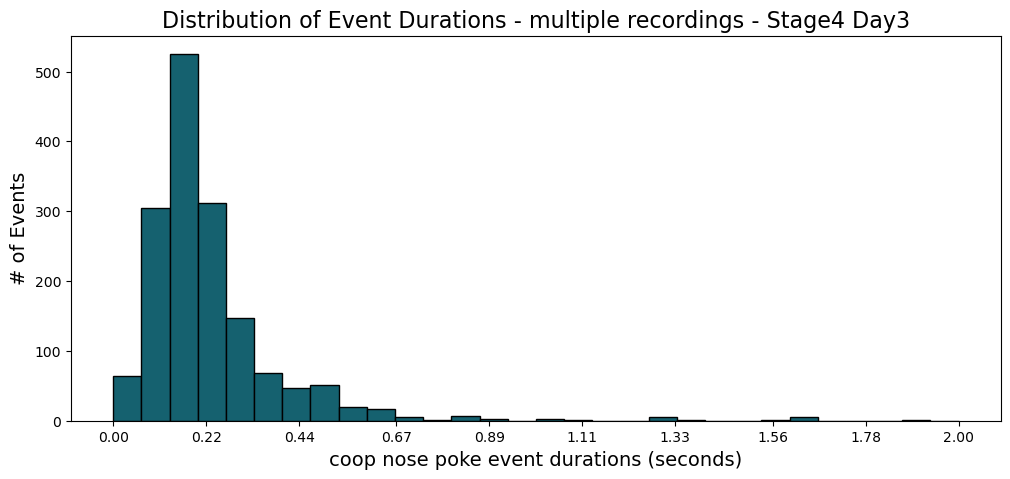

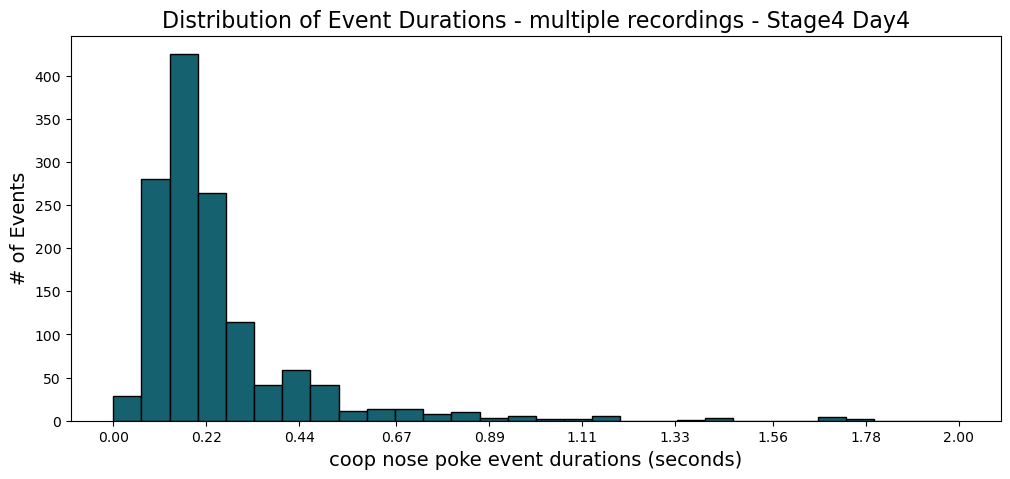

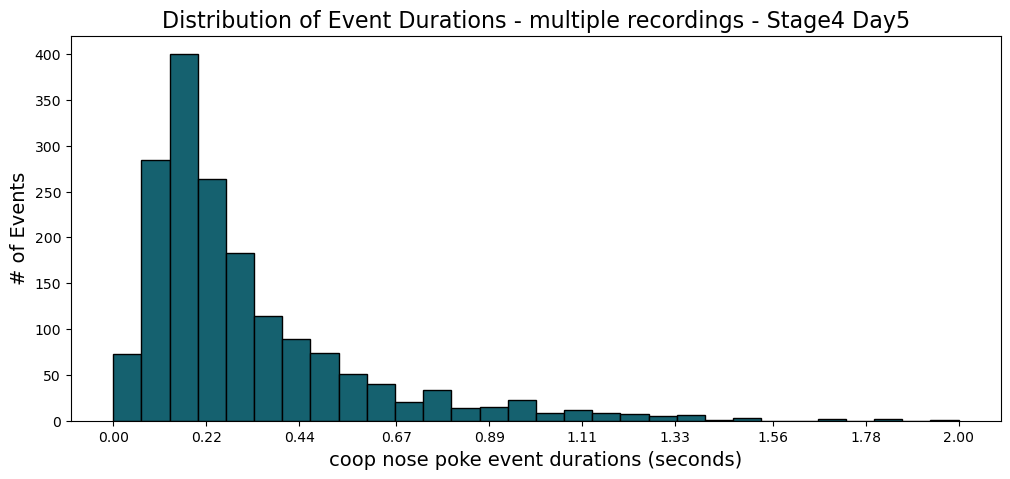

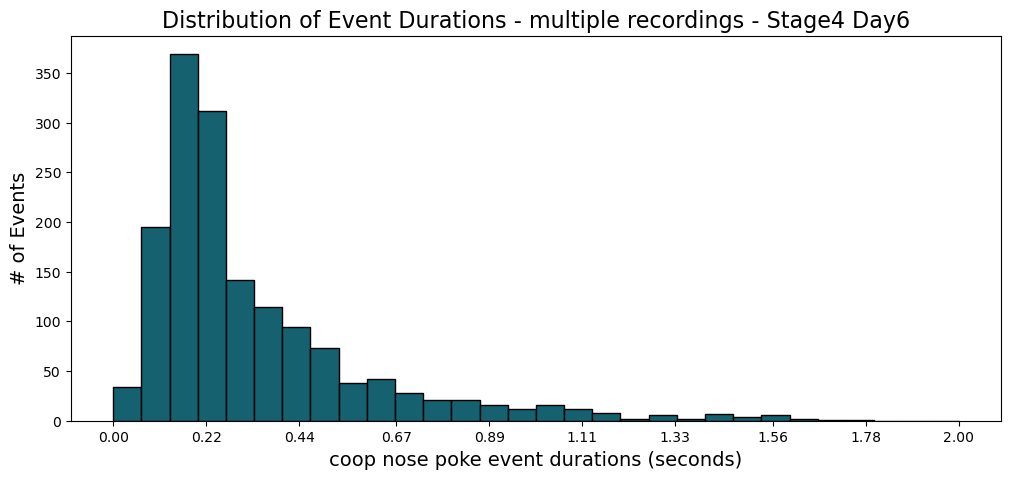

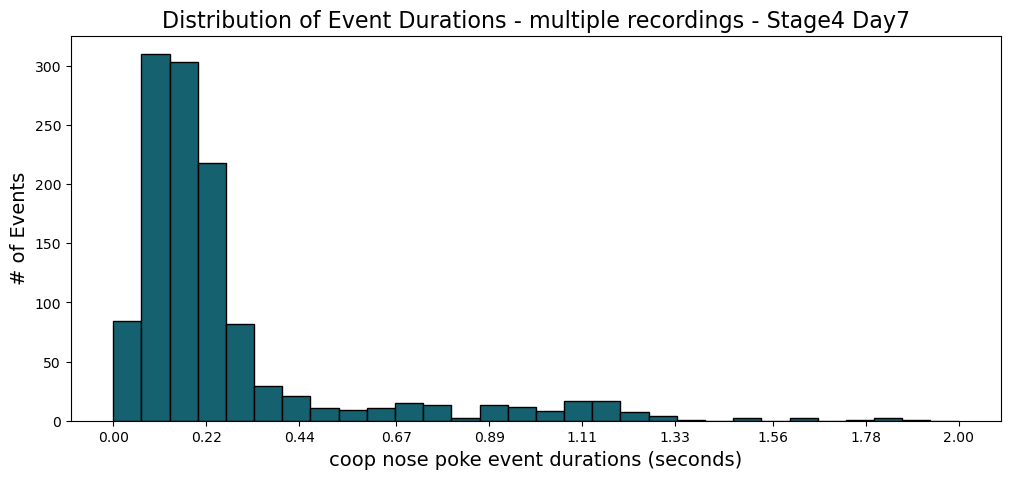

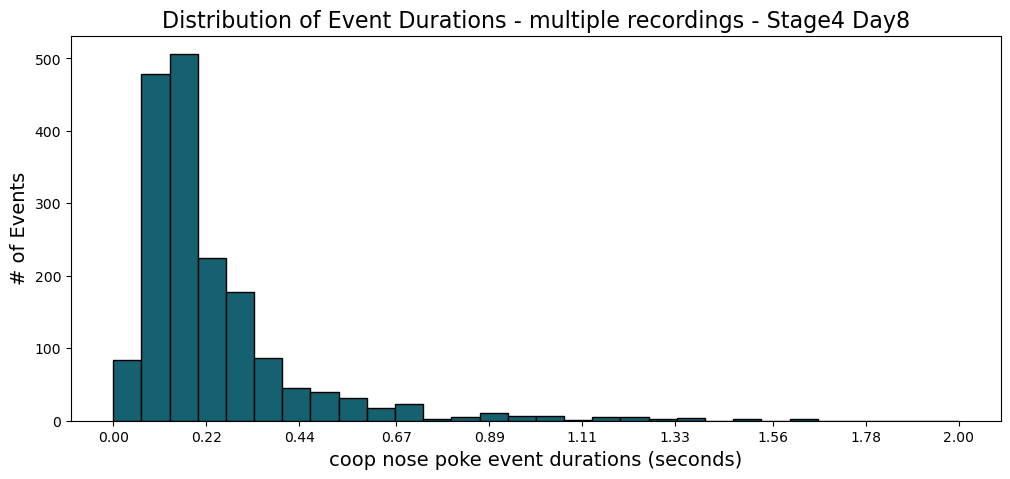

In [18]:
for i in range(8):
	events_duration_distribution(Stage4[i], "coop nose poke", day= i+1, xmax=2)

### Selfish Nose Poke

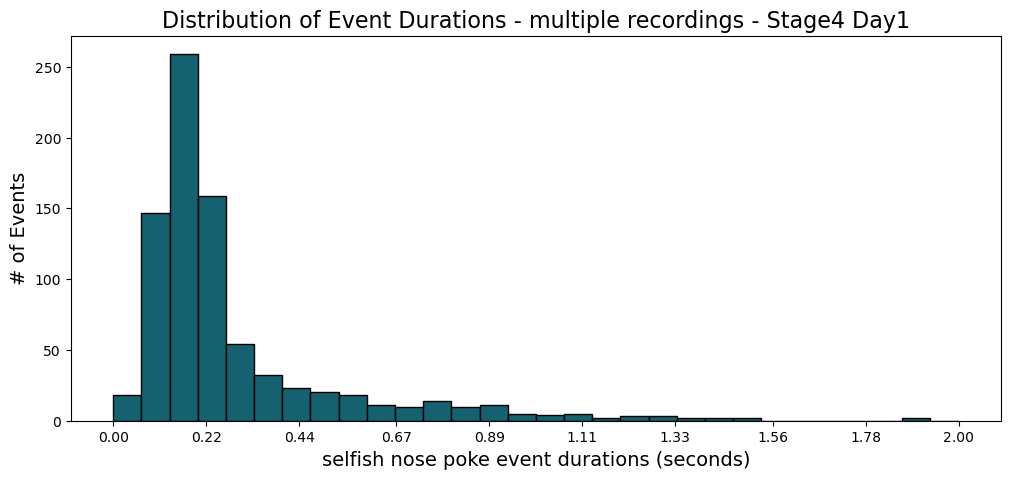

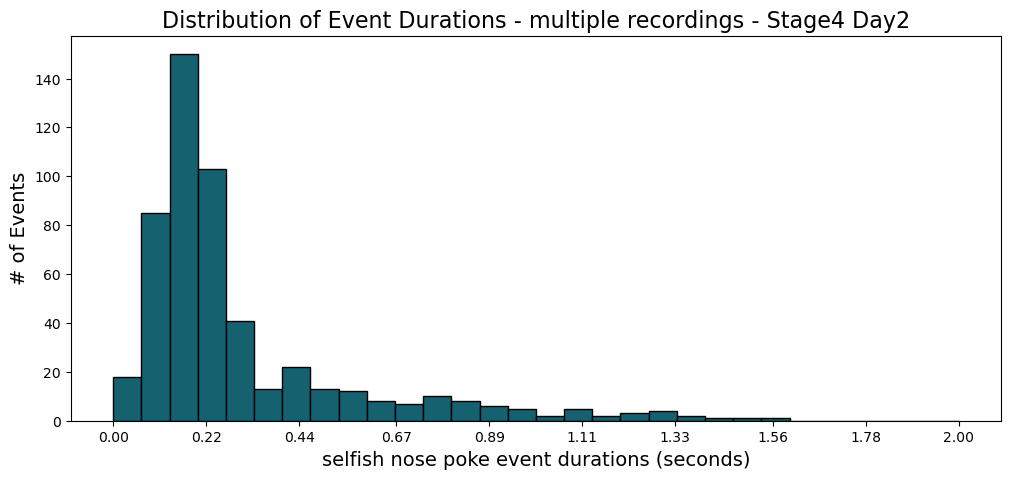

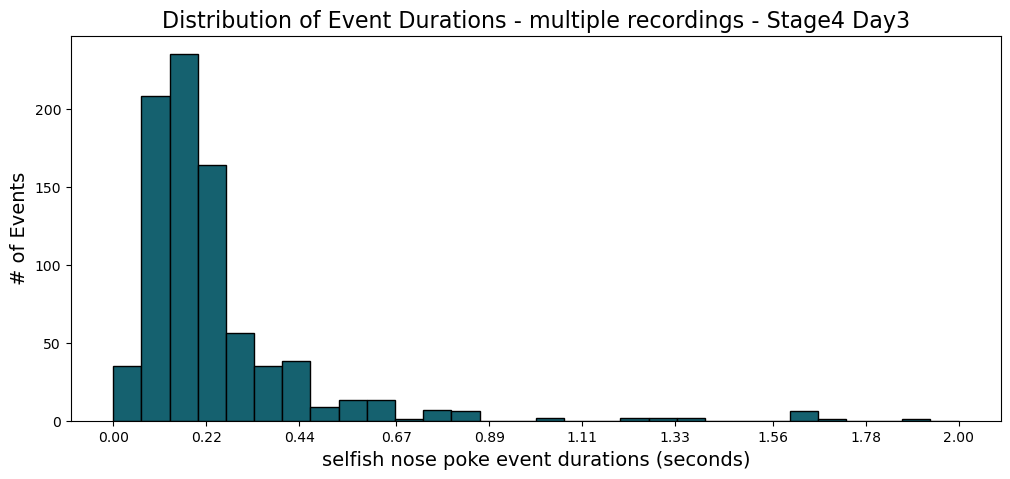

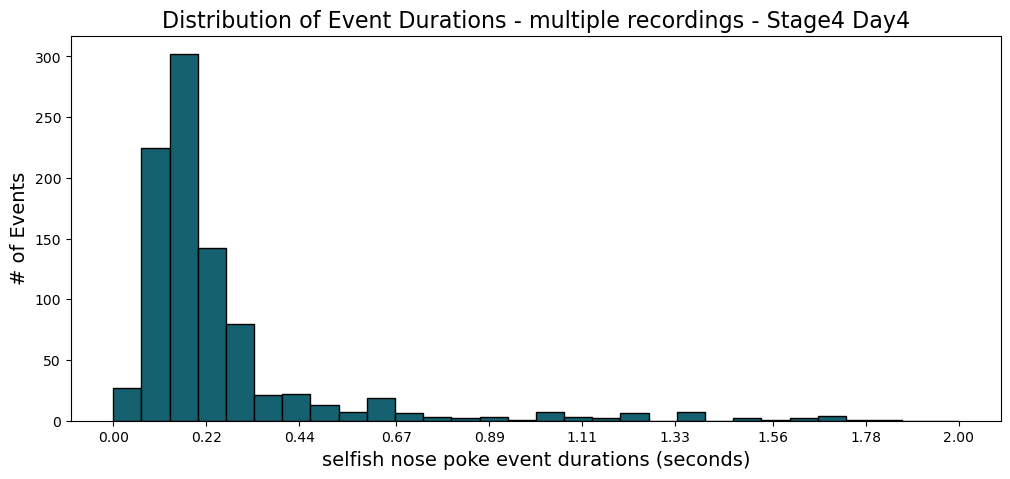

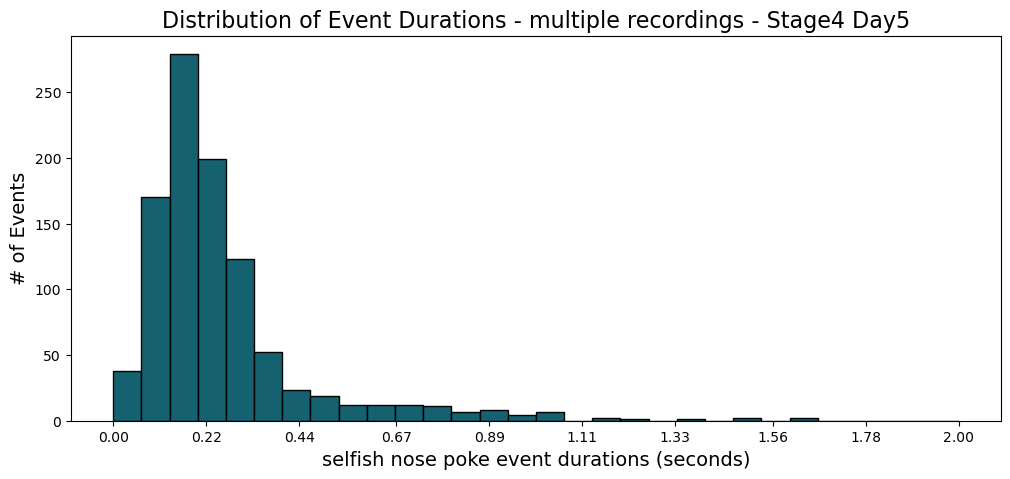

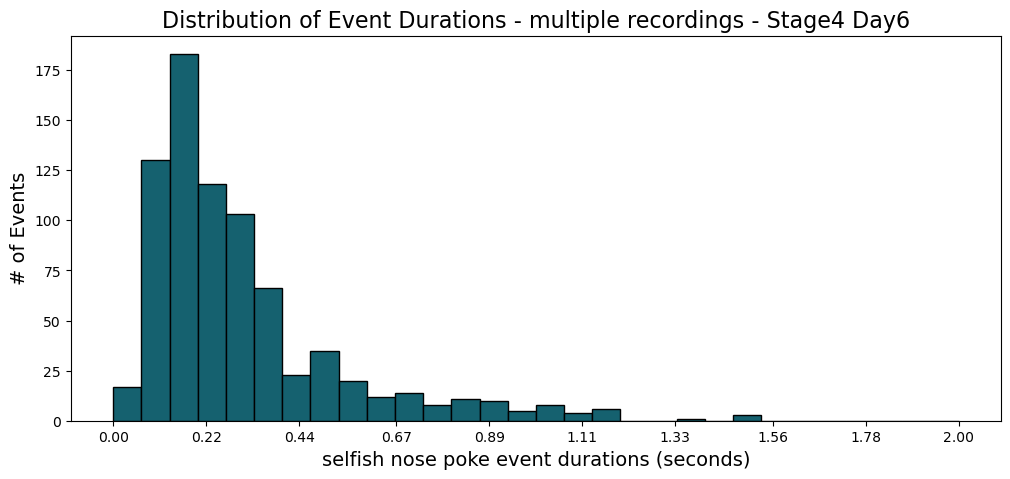

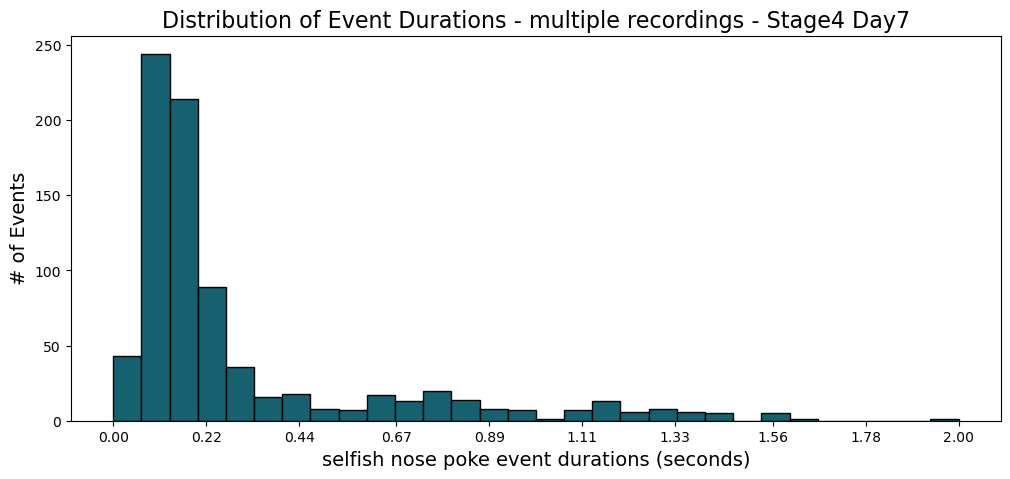

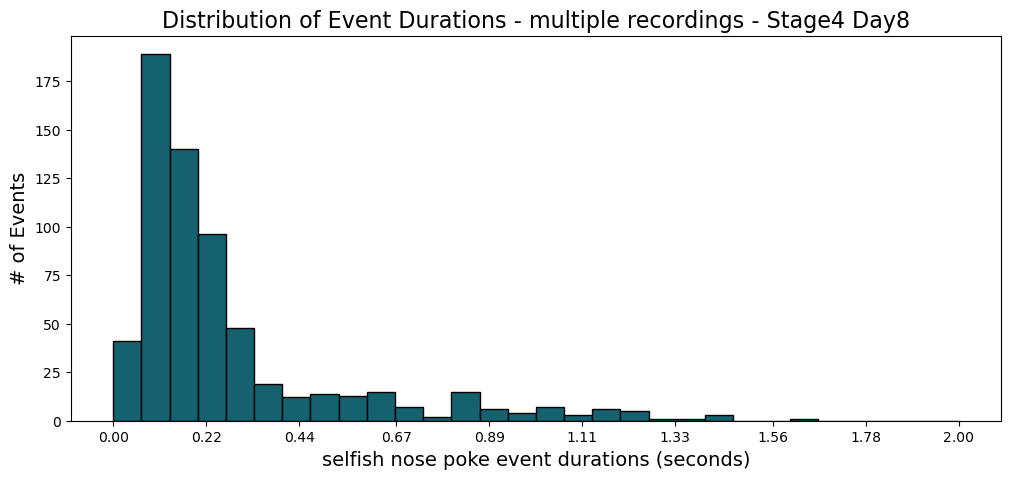

In [19]:
for i in range(8):
	events_duration_distribution(Stage4[i], "selfish nose poke", day= i+1, xmax=2)

### Subject Port Entry

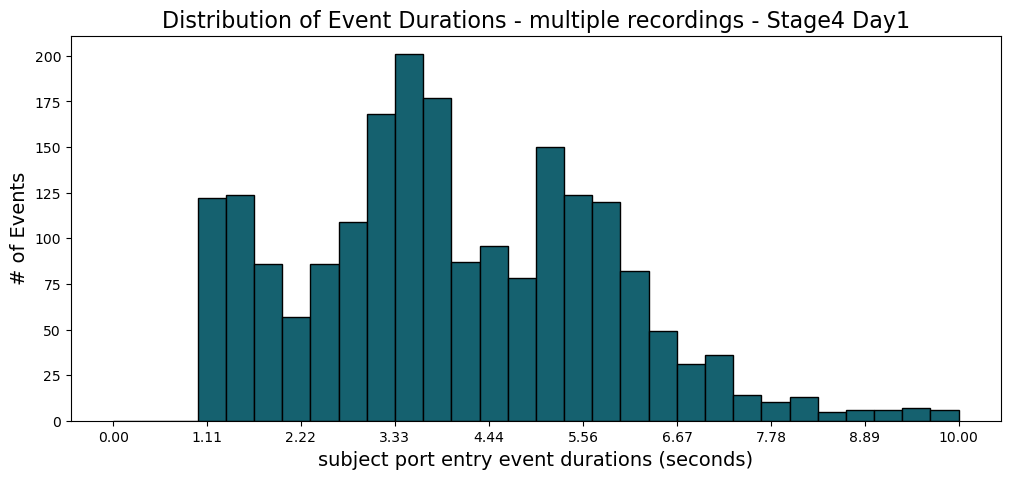

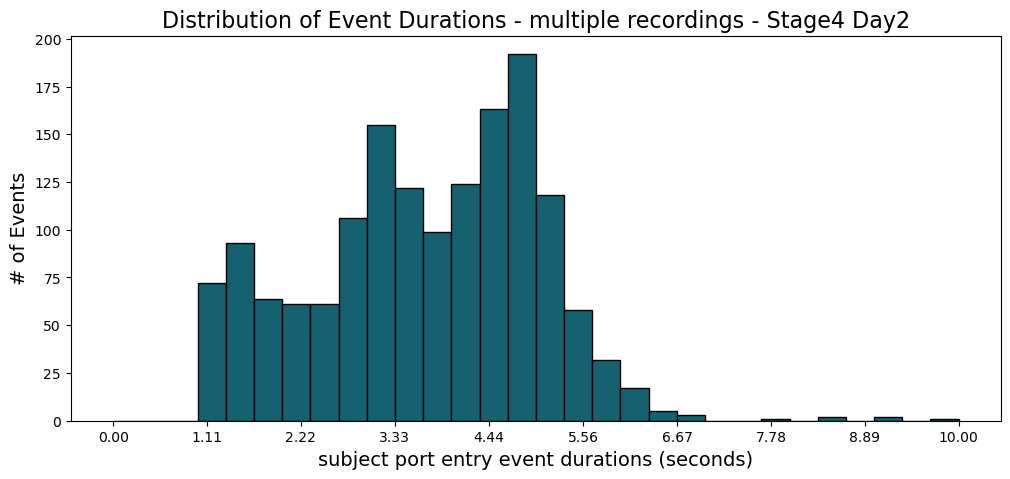

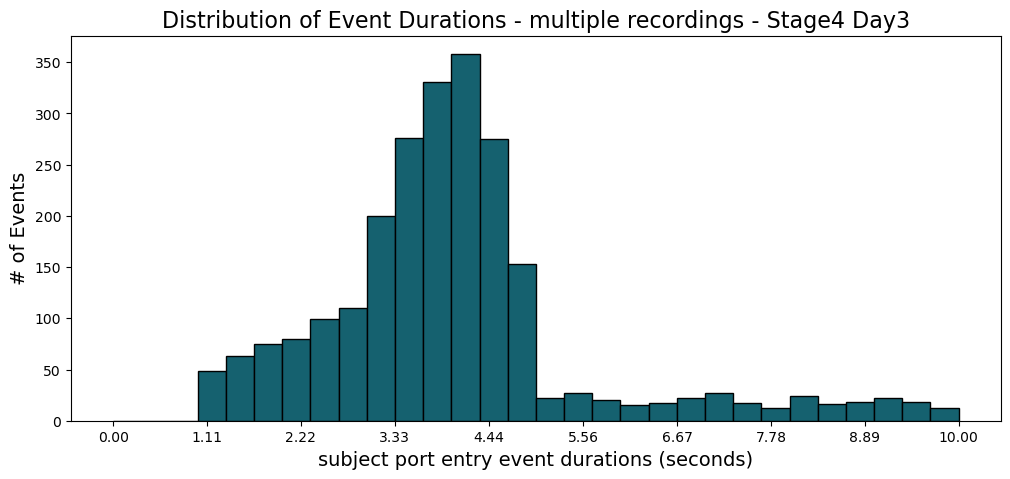

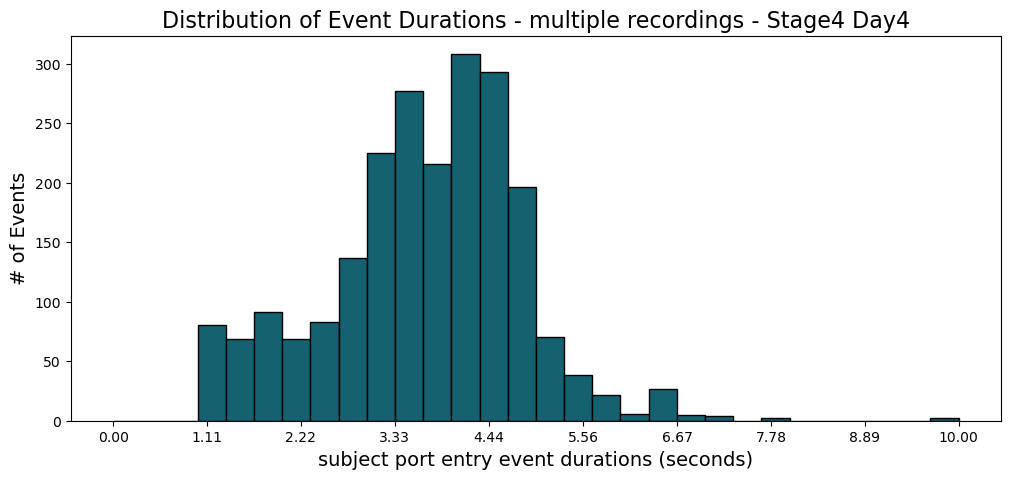

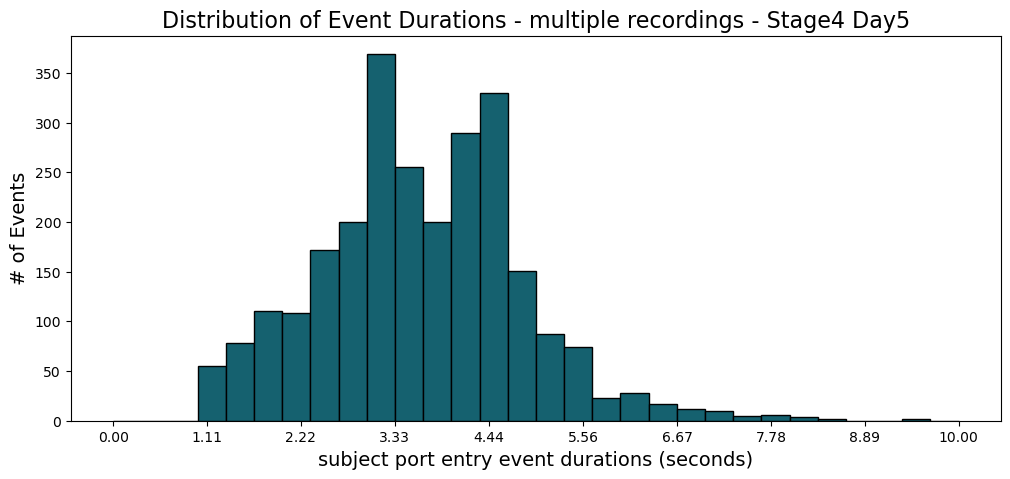

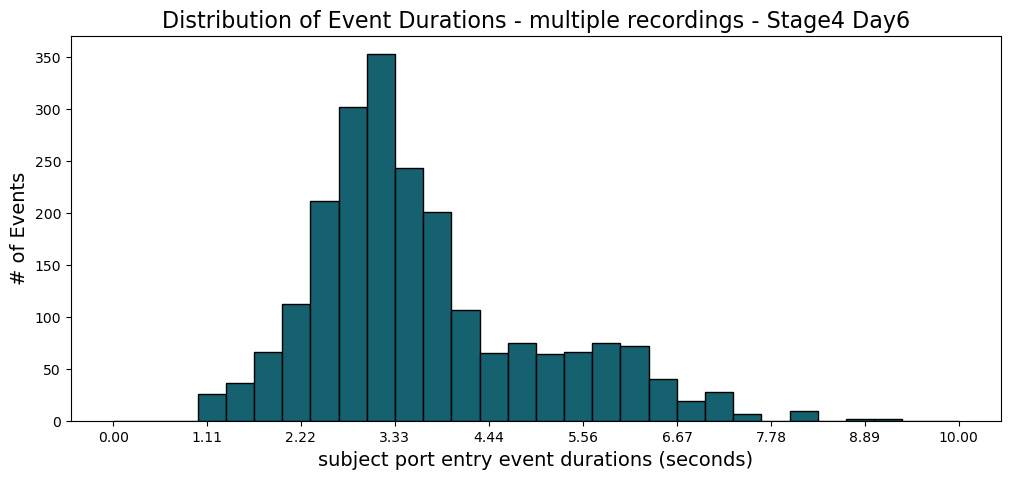

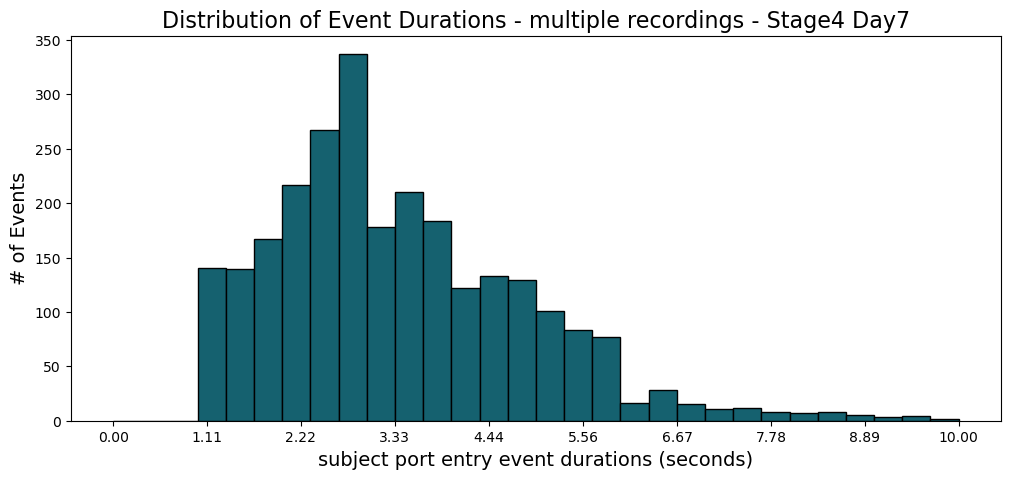

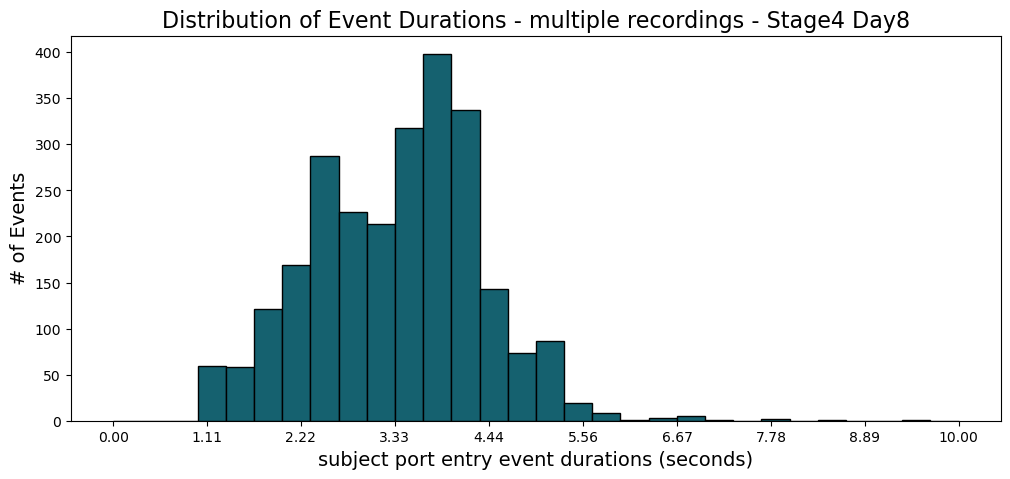

In [20]:
for i in range(8):
	events_duration_distribution(Stage4[i], "subject port entry", day= i+1, xmax=10)

### Recipient Port Entry

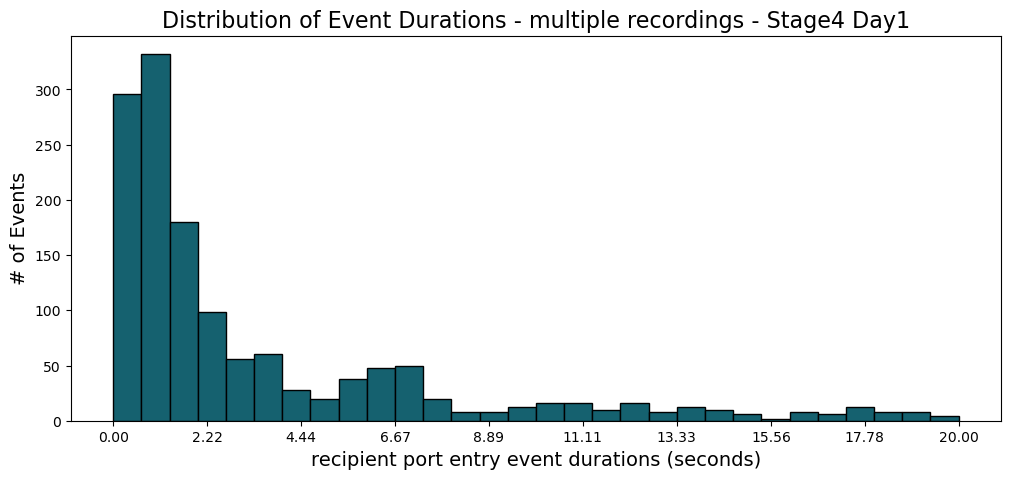

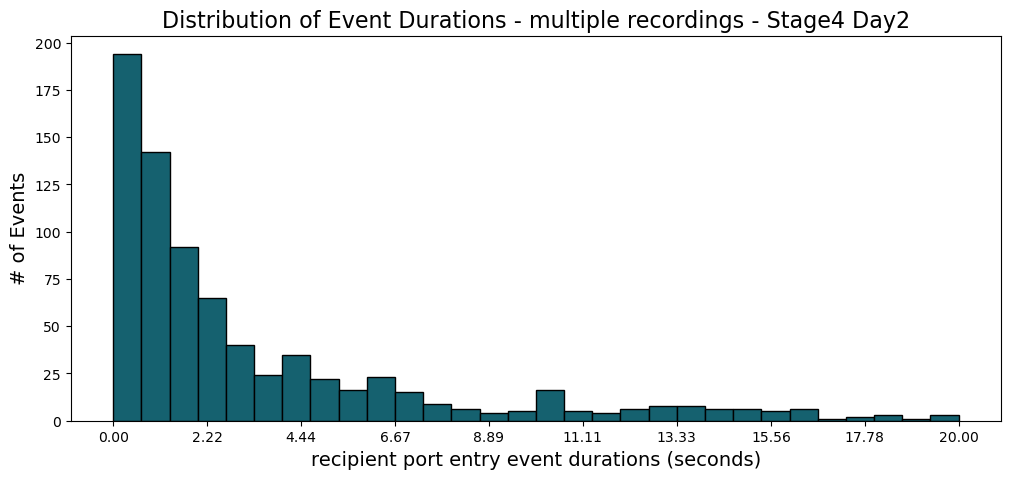

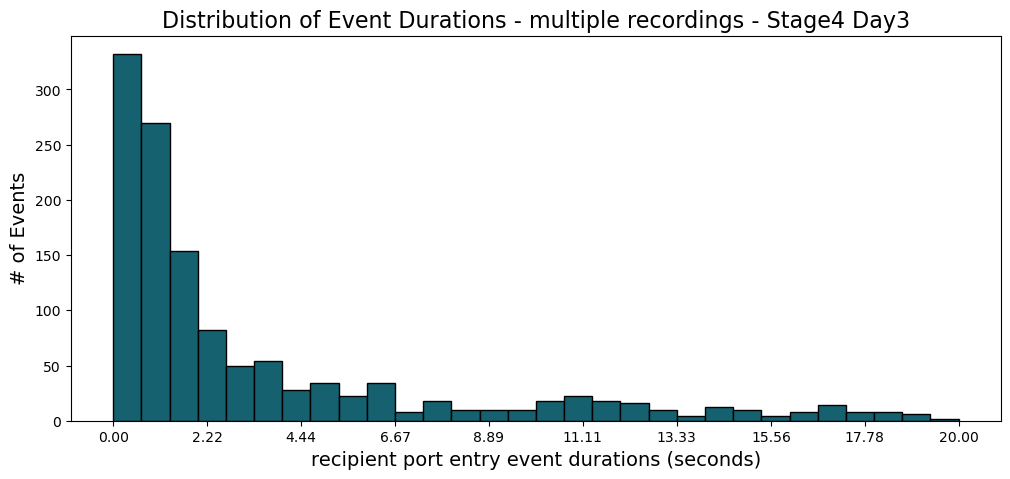

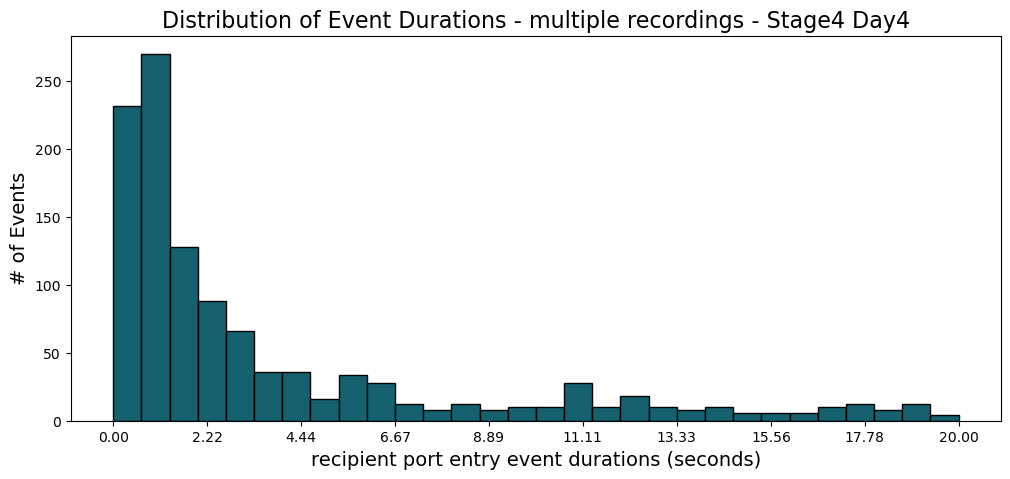

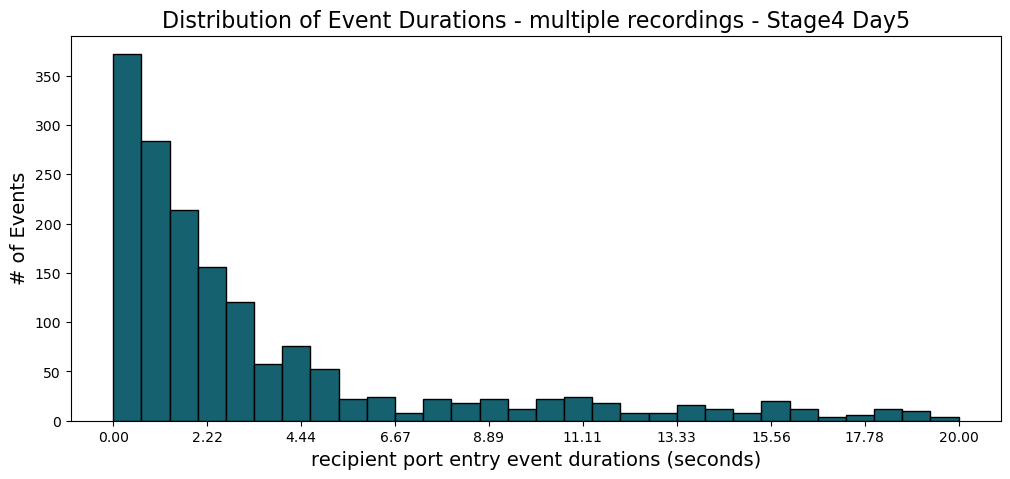

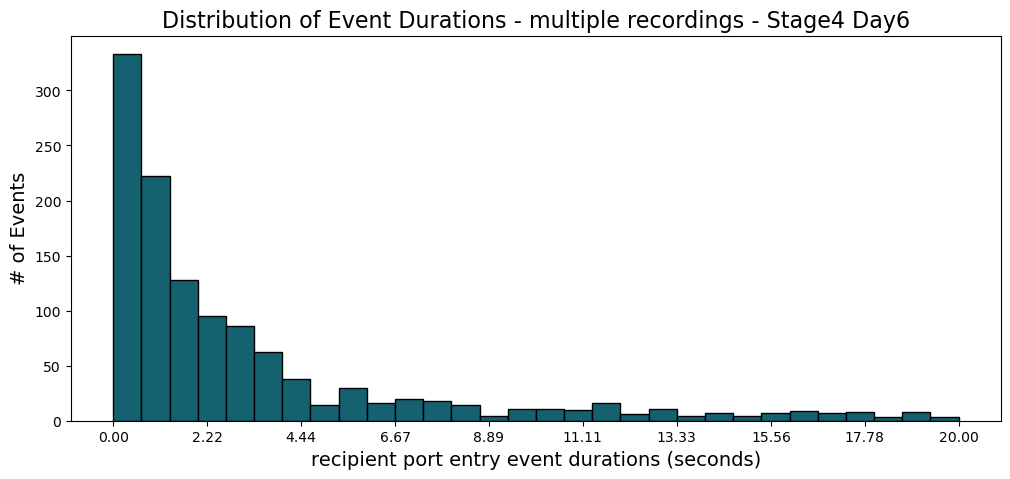

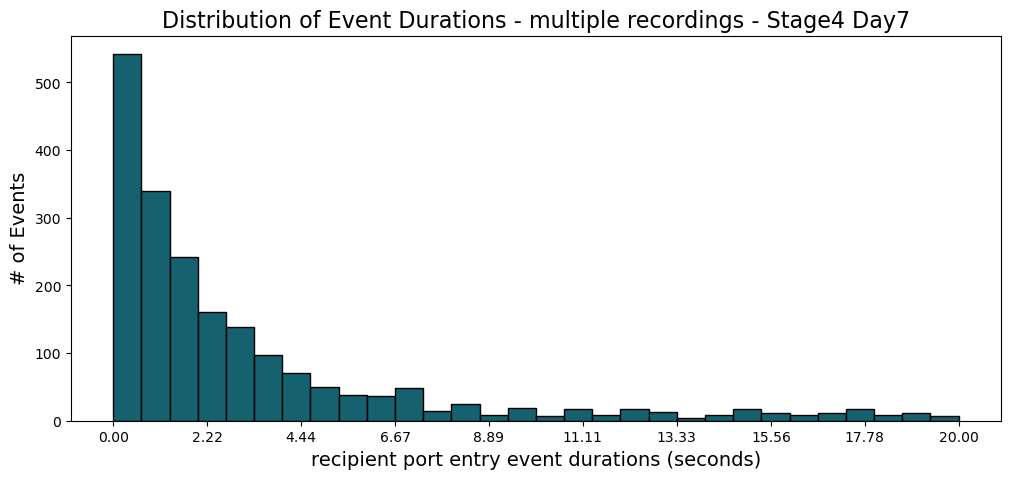

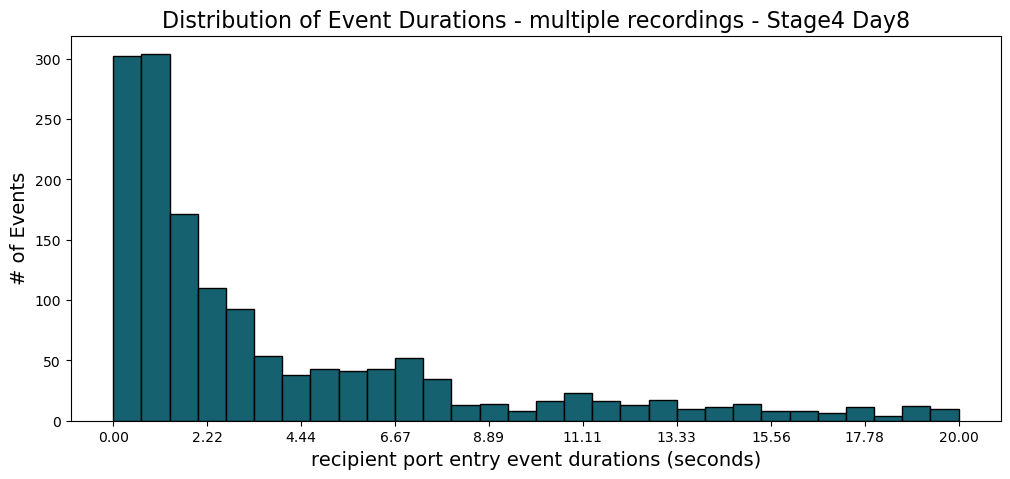

In [21]:
for i in range(8):
	events_duration_distribution(Stage4[i], "recipient port entry", day= i+1, xmax=20)

# 4. Pickle Processed Events

In [22]:
for i in range(8):
	pkl_path = os.path.join(path, 'Processed_Events', f'Stage4_D{i+1}.pkl')
	pickle_this(Stage4[i], pkl_path)

# 5. Events Across Time

In [23]:
def plot_recordings_behaviors(stage_list, behavior_order=None, time_window=None, day=None):
    """Plot one figure per recording showing every behavior as a horizontal bar.

    Parameters
    ----------
    stage_list : list
        list of dictionaries where each dictionary corresponds to a day/stage.
        Each is keyed by recording name and maps to a dict of behavior names to
        an (N,2) array of start/stop times.
    behavior_order : list, optional
        explicit order of behaviors to display. If ``None`` the union of all
        behaviors across recordings is used (sorted alphabetically).
    time_window : tuple(float, float) or None
        if provided, only events that fall within the window are shown and the
        x-axis limits are set accordingly.  Use (xmin, xmax).
    day : int or None
        if provided, limits plotting to that one day (1-based index).  ``None``
        plots all days in the list.
    """
    # build a common ordering if the caller didn't supply one
    if behavior_order is None:
        behaviors = set()
        for stage in stage_list:
            for rec_dict in stage.values():
                behaviors.update(rec_dict.keys())
        behavior_order = sorted(behaviors)

    # helper for plotting a single recording
    def _plot_single(rec_name, rec_beh):
        # create a dict containing every behavior in the desired order
        ordered = {b: np.array(rec_beh.get(b, [])) for b in behavior_order}
        n_beh = len(ordered)
        fig, ax = plt.subplots(figsize=(10, 0.6 * n_beh))
        color_map = {label: [np.random.random() for _ in range(3)] for label in ordered}

        yticks = []
        yticklabels = []
        for i, (label, events) in enumerate(ordered.items()):
            y = n_beh - 1 - i
            for start, stop in events:
                # skip events outside time_window if specified
                if time_window is not None:
                    xmin, xmax = time_window
                    if stop < xmin or start > xmax:
                        continue
                    start = max(start, xmin)
                    stop = min(stop, xmax)
                ax.barh(y, stop - start, left=start, height=0.4,
                        color=color_map[label], edgecolor="black")
            yticks.append(y)
            yticklabels.append(label)

        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels)
        ax.set_xlabel("Time")
        if time_window is not None:
            ax.set_xlim(time_window)
        ax.set_title(rec_name)
        ax.grid(True, axis="x", linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    # possibly restrict to a single day
    days_to_plot = stage_list
    if day is not None:
        # convert 1-based day index to 0-based
        idx = day - 1
        if idx < 0 or idx >= len(stage_list):
            raise ValueError(f"day must be between 1 and {len(stage_list)}")
        days_to_plot = [stage_list[idx]]

    # iterate through selected recordings and produce a figure
    for stage_idx, stage in enumerate(days_to_plot, start=(day or 1)):
        for rec, rec_beh in stage.items():
            _plot_single(f"Stage{stage_idx} {rec}", rec_beh)


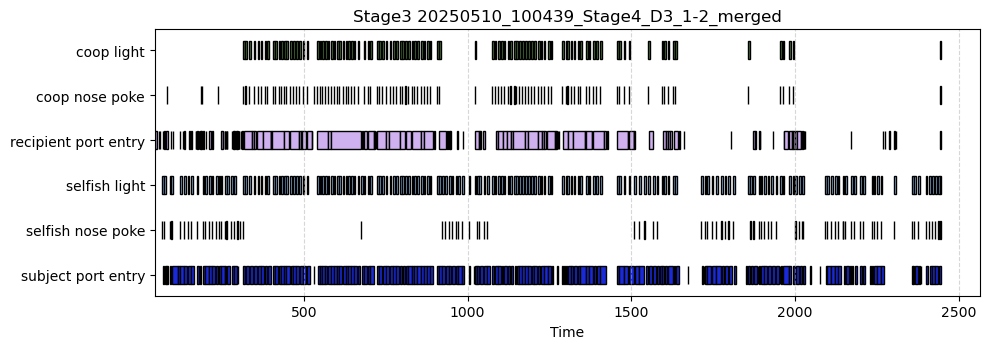

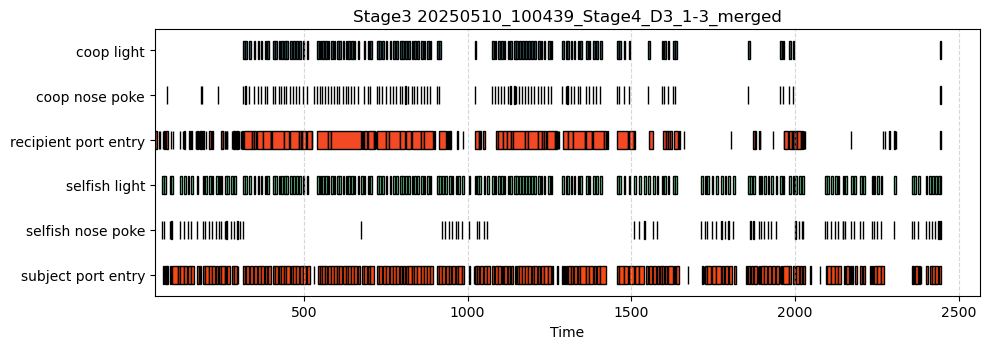

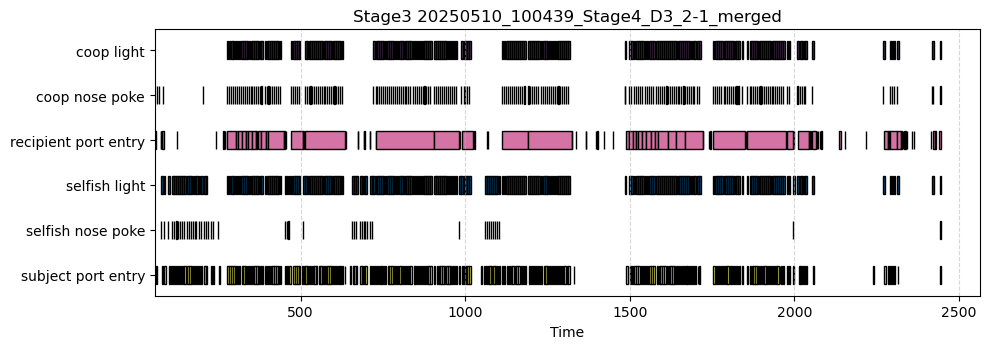

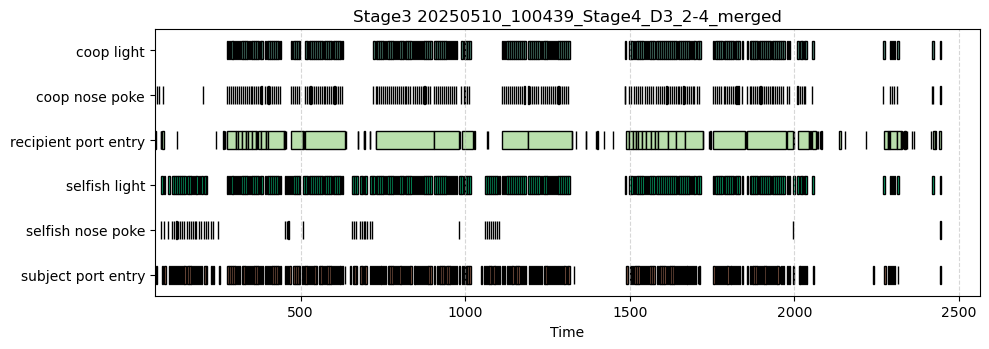

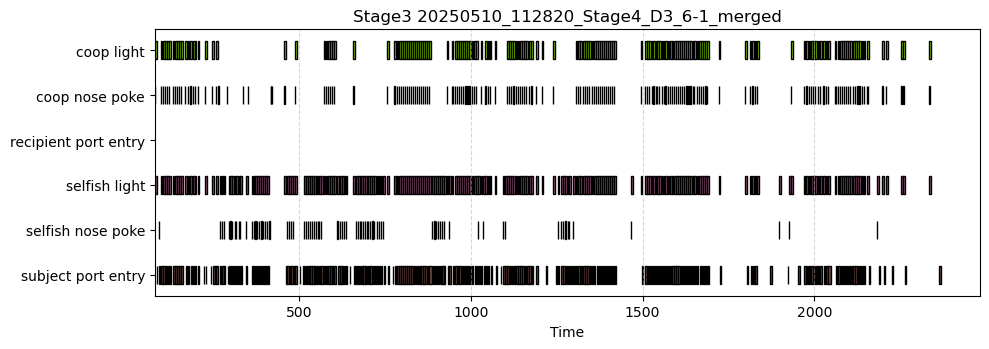

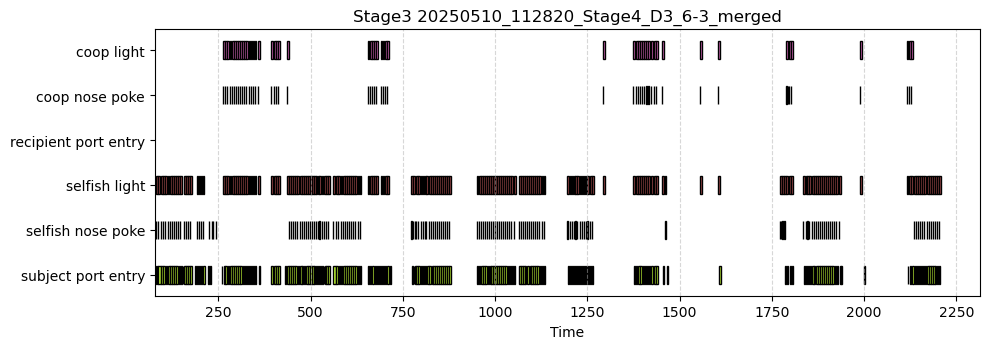

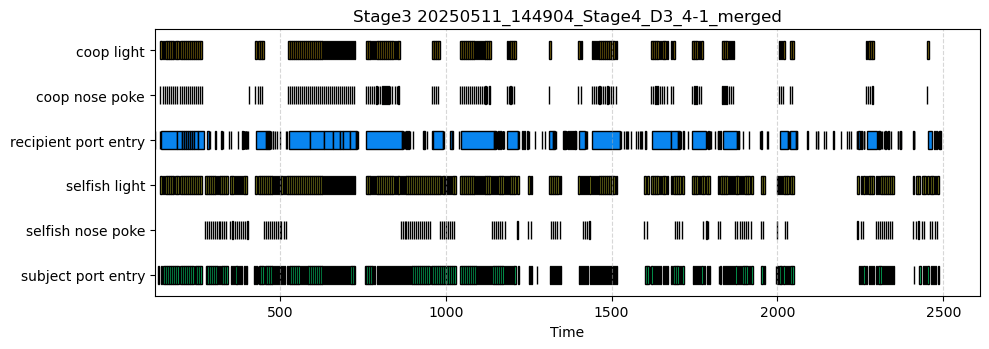

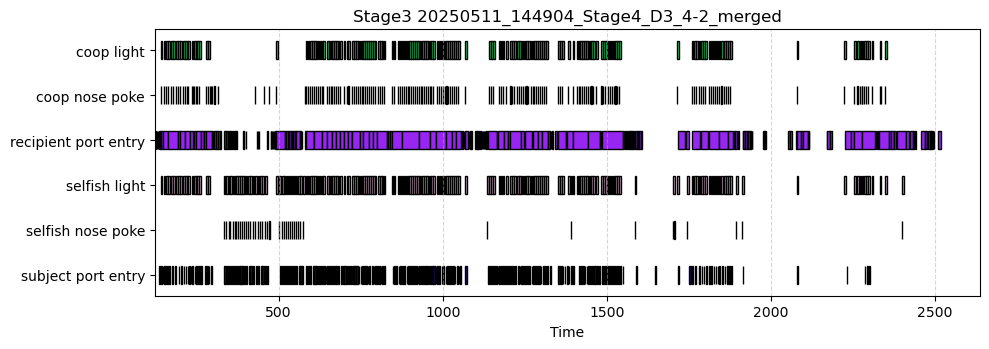

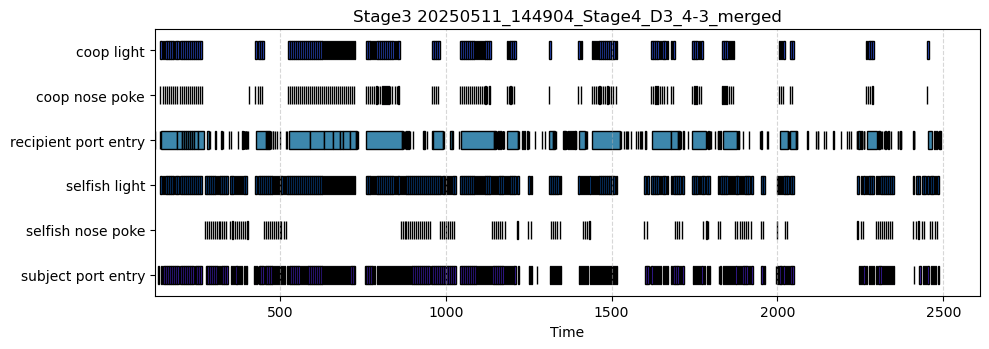

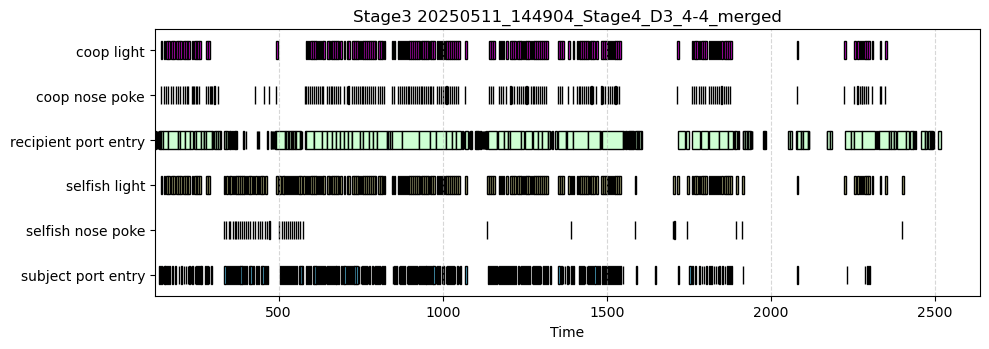

In [28]:
# only plot day 3 of stage 4, full time axis
plot_recordings_behaviors(Stage4, day=3)


# 6. 2s ITI Windows

In [19]:
def find_iti_windows(recording_behaviors, window_duration=2.0, time_bounds=None):
    """
    Find non-overlapping 2-second ITI (inter-trial interval) windows in a recording.
    
    ITI windows are defined as periods where no behavioral events occur.
    Overlapping events are merged before gap detection.
    
    Parameters
    ----------
    recording_behaviors : dict
        Dictionary mapping behavior names to (n, 2) arrays of [start, end] times
    window_duration : float, optional
        Duration of ITI window to find (default: 2.0 seconds)
    time_bounds : tuple(float, float), optional
        Recording time bounds (min_time, max_time). If None, uses data range.
    
    Returns
    -------
    int
        Number of non-overlapping 2-second ITI windows
    """
    
    # Collect all events from all behaviors
    all_events = []
    for behavior_name, events in recording_behaviors.items():
        if len(events) > 0:
            all_events.extend([tuple(event) for event in events])
    
    if not all_events:
        # No events, entire recording is ITI
        return 0
    
    # Sort events by start time
    all_events.sort(key=lambda x: x[0])
    all_events = np.array(all_events)
    
    # Merge overlapping events
    merged_events = [all_events[0]]
    for current_event in all_events[1:]:
        last_event = merged_events[-1]
        # If current event starts before last event ends, they overlap - merge them
        if current_event[0] < last_event[1]:
            # Extend the last event to include the current event
            merged_events[-1] = [last_event[0], max(last_event[1], current_event[1])]
        else:
            # No overlap, add as new event
            merged_events.append(current_event)
    
    merged_events = np.array(merged_events)
    
    # Find time bounds if not provided
    if time_bounds is None:
        # Assume recording starts at 0 and ends after the last event
        min_time = 0
        max_time = merged_events[:, 1].max() + 10  # Add buffer
    else:
        min_time, max_time = time_bounds
    
    # Find all gaps between merged events
    gaps = []
    
    # Gaps between consecutive merged events
    for i in range(len(merged_events) - 1):
        gap_start = merged_events[i, 1]
        gap_end = merged_events[i + 1, 0]
        if gap_end > gap_start:
            gaps.append((gap_start, gap_end))
    
    # Gap after last event
    gaps.append((merged_events[-1, 1], max_time))
    
    # Count how many 2-second windows fit in each gap without overlapping
    total_windows = 0
    for gap_start, gap_end in gaps:
        gap_duration = gap_end - gap_start
        if gap_duration >= window_duration:
            # Number of non-overlapping windows that fit in this gap
            num_windows = int(gap_duration // window_duration)
            total_windows += num_windows
    
    return total_windows

In [20]:
find_iti_windows(Stage4[0]['20250508_100203_Stage4_D1_1-2_merged'])

152

In [21]:
# Analyze 2s ITI windows across all days and recordings
print("=" * 60)
print("2-SECOND ITI WINDOW ANALYSIS")
print("=" * 60)

for day_idx, day_data in enumerate(Stage4, start=1):
    print(f"\n--- Day {day_idx} ---")
    for recording_name, behaviors_dict in day_data.items():
        num_windows = find_iti_windows(behaviors_dict, window_duration=2.0)
        print(f"{recording_name}: {num_windows} 2s ITI windows")

2-SECOND ITI WINDOW ANALYSIS

--- Day 1 ---
20250508_100203_Stage4_D1_1-2_merged: 152 2s ITI windows
20250508_100203_Stage4_D1_1-3_merged: 152 2s ITI windows
20250508_100203_Stage4_D1_2-1_merged: 343 2s ITI windows
20250508_100203_Stage4_D1_2-4_merged: 343 2s ITI windows
20250508_112121_Stage4_D1_6-1_merged: 318 2s ITI windows
20250508_112121_Stage4_D1_6-3_merged: 557 2s ITI windows
20250509_131426_Stage4_D1_4-1_merged: 105 2s ITI windows
20250509_131426_Stage4_D1_4-2_merged: 80 2s ITI windows
20250509_131426_Stage4_D1_4-3_merged: 105 2s ITI windows
20250509_131426_Stage4_D1_4-4_merged: 80 2s ITI windows

--- Day 2 ---
20250509_094358_Stage4_D2_1-2_merged: 228 2s ITI windows
20250509_094358_Stage4_D2_1-3_merged: 228 2s ITI windows
20250509_094358_Stage4_D2_2-1_merged: 267 2s ITI windows
20250509_110531_Stage4_D2_6-1_merged: 403 2s ITI windows
20250509_110531_Stage4_D2_6-3_merged: 565 2s ITI windows
20250510_130636_Stage4_D2_4-3_merged: 284743 2s ITI windows
20250510_130636_Stage4_D2_4-